<a href="https://colab.research.google.com/github/PauSolum/analisis-neuronal-insectos/blob/main/Taller2_Jara_L%C3%B3pez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 2 · De 16 canales a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [ ]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


1. ATRIBUTOS DEL ARCHIVO
   descripcion: Sonda lineal de 16 sitios, registro limpio sin estimulos. Curso: De la neurona a la figura, Taller 2.
   duracion_s: 90.0
   escala_uV_por_bit: 0.195
   frecuencia_muestreo_hz: 15000
   n_canales: 16
   unidades: microvoltios tras multiplicar por escala_uV_por_bit

Frecuencia de muestreo: 15000 Hz
Factor de conversión: 0.195 µV/bit

2. CONTENIDO DEL ARCHIVO

Grupo: geometria
   Atributo -> nota: Sonda lineal de 16 sitios separados 50 um. canal_y_um es la profundidad de cada sitio.
Dataset: geometria/canal_x_um
   shape: (16,)
   dtype: float64
Dataset: geometria/canal_y_um
   shape: (16,)
   dtype: float64

Grupo: registro
   Atributo -> forma: canales x muestras
Dataset: registro/datos
   shape: (16, 1350000)
   dtype: int16

Grupo: verdad
   Atributo -> nota: unidad: 1..N = unidad bien aislada (good); 0 = neurona de fondo (MUA); -1 = artefacto (noise). Los cruces del umbral por ruido termico no estan aqui: no son potenciales de accion.
Dataset

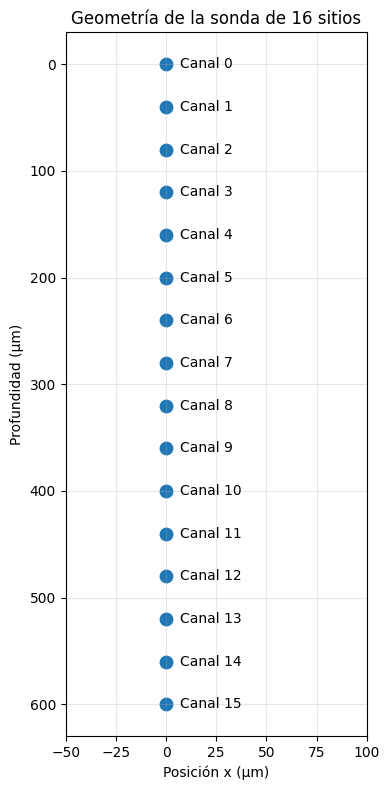

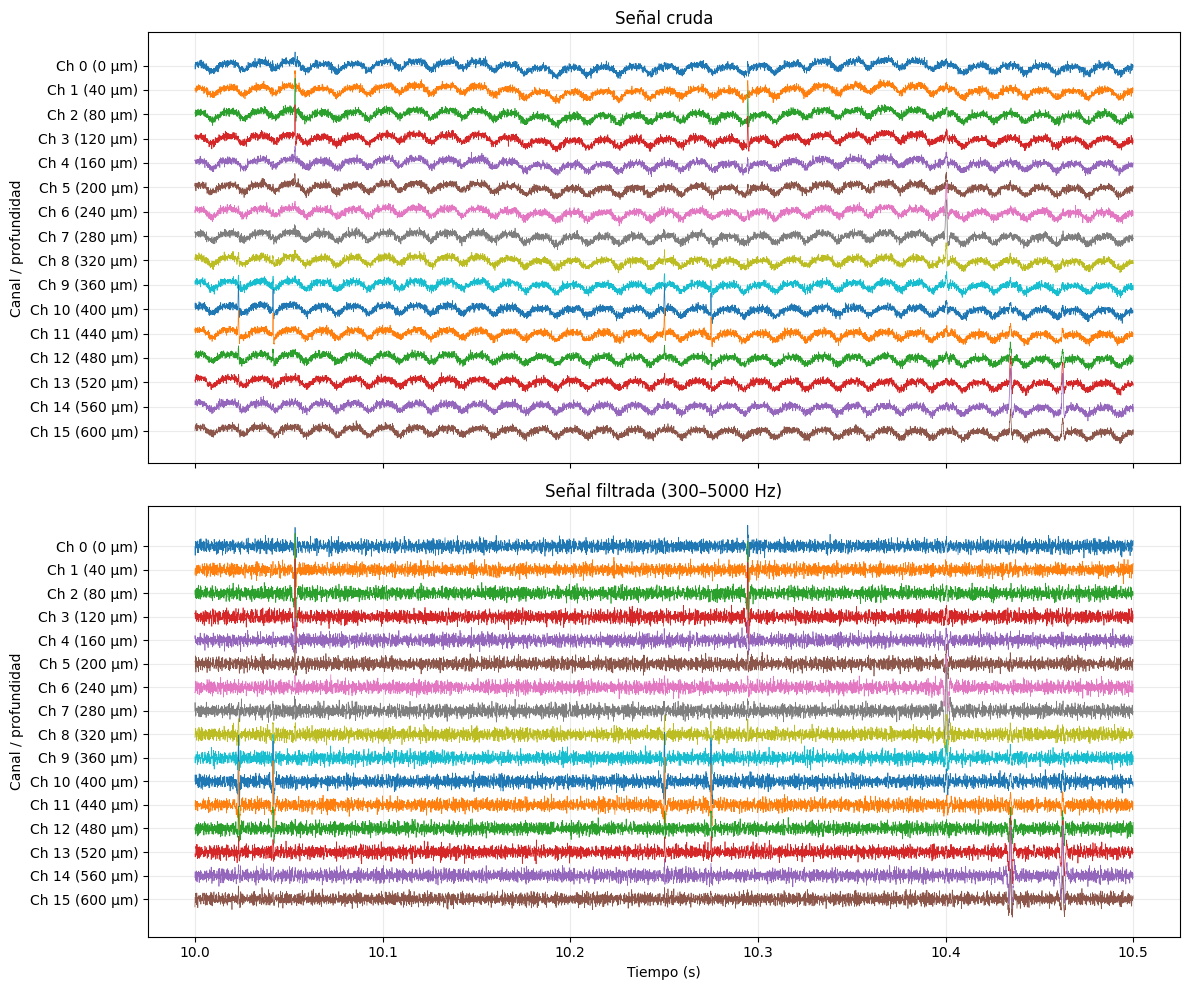

In [ ]:
# ✏️ Ejercicio 1

# a)

ARCHIVO = "taller2_limpia.h5"

with h5py.File(ARCHIVO, "r") as f:

    # 1. Atributos generales del archivo
    print("1. ATRIBUTOS DEL ARCHIVO")
    for nombre, valor in f.attrs.items():
        print(f"   {nombre}: {valor}")

    # Frecuencia de muestreo y factor de conversión
    fs = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])

    print(f"\nFrecuencia de muestreo: {fs} Hz")
    print(f"Factor de conversión: {escala} µV/bit")


    # 2. Explorar grupos y datasets
    print("\n2. CONTENIDO DEL ARCHIVO")

    def explorar(nombre, objeto):
        if isinstance(objeto, h5py.Group):
            print(f"\nGrupo: {nombre}")

            # Mostrar atributos del grupo, si tiene
            for atributo, valor in objeto.attrs.items():
                print(f"   Atributo -> {atributo}: {valor}")

        elif isinstance(objeto, h5py.Dataset):
            print(f"Dataset: {nombre}")
            print(f"   shape: {objeto.shape}")
            print(f"   dtype: {objeto.dtype}")

    f.visititems(explorar)


    # 3. Geometría de la sonda
    print("\n3. GEOMETRÍA DE LA SONDA")

    geometria = f["geometria"]

    for nombre in geometria.keys():
        datos = geometria[nombre][:]

        print(f"\nDataset: geometria/{nombre}")
        print(f"   shape: {datos.shape}")
        print(f"   valores:")
        print(datos)

# b)

with h5py.File(ARCHIVO, "r") as f:
    x = f["geometria/canal_x_um"][:]
    y = f["geometria/canal_y_um"][:]

fig, ax = plt.subplots(figsize=(4, 8))

# Dibujar cada sitio de la sonda
ax.scatter(x, y, s=80)

# Poner el número de canal al lado de cada sitio
for canal in range(len(x)):
    ax.annotate(
        f"Canal {canal}",
        (x[canal], y[canal]),
        xytext=(10, 0),
        textcoords="offset points",
        va="center"
    )

# Como todos los canales están en x = 0,
# damos un poco de espacio horizontal para poder verlos
ax.set_xlim(-50, 100)

# La profundidad aumenta hacia abajo
ax.invert_yaxis()

ax.set_xlabel("Posición x (µm)")
ax.set_ylabel("Profundidad (µm)")
ax.set_title("Geometría de la sonda de 16 sitios")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# C)

ARCHIVO = "taller2_limpia.h5"

with h5py.File(ARCHIVO, "r") as f:

    # Datos generales
    fs = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])

    # Cargar los 16 canales y convertirlos a µV
    cruda = f["registro/datos"][:].astype(np.float32) * escala

    # Profundidad de cada canal
    profundidad = f["geometria/canal_y_um"][:]


# ---------- Ordenar canales por profundidad ----------

orden = np.argsort(profundidad)

cruda = cruda[orden]
profundidad = profundidad[orden]

canales = np.arange(16)[orden]


# ---------- Filtro pasa-banda 300 - 5000 Hz ----------

sos = butter(
    4,
    [300, 5000],
    btype="bandpass",
    fs=fs,
    output="sos"
)

filtrada = sosfiltfilt(sos, cruda, axis=1)


# ---------- Elegir una ventana de 0.5 segundos ----------

inicio_s = 10
duracion_s = 0.5

inicio = int(inicio_s * fs)
fin = int((inicio_s + duracion_s) * fs)

t = np.arange(inicio, fin) / fs

cruda_ventana = cruda[:, inicio:fin]
filtrada_ventana = filtrada[:, inicio:fin]


# ---------- Separación visual entre canales ----------

# Se calcula automáticamente para que las señales no queden montadas
offset_cruda = 2.5 * np.percentile(np.abs(cruda_ventana), 99)
offset_filtrada = 2.5 * np.percentile(np.abs(filtrada_ventana), 99)


# ---------- Graficar ----------

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True
)

# Señal cruda
for i in range(16):
    ax1.plot(
        t,
        cruda_ventana[i] + i * offset_cruda,
        linewidth=0.5
    )

ax1.set_title("Señal cruda")
ax1.set_ylabel("Canal / profundidad")

ax1.set_yticks(np.arange(16) * offset_cruda)
ax1.set_yticklabels(
    [f"Ch {c} ({p:.0f} µm)" for c, p in zip(canales, profundidad)]
)

ax1.invert_yaxis()


# Señal filtrada
for i in range(16):
    ax2.plot(
        t,
        filtrada_ventana[i] + i * offset_filtrada,
        linewidth=0.5
    )

ax2.set_title("Señal filtrada (300–5000 Hz)")
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Canal / profundidad")

ax2.set_yticks(np.arange(16) * offset_filtrada)
ax2.set_yticklabels(
    [f"Ch {c} ({p:.0f} µm)" for c, p in zip(canales, profundidad)]
)

ax2.invert_yaxis()

plt.tight_layout()
plt.show()


**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

Selección Múltiple: B

Pregunta abierta: No, un evento que aparece simultáneamente en los 16 canales probablemente no corresponde a una neurona, sino a un artefacto. Como la amplitud de una señal neuronal disminuye aproximadamente como \(1/r\), debería ser mayor en los canales cercanos a la neurona y disminuir al aumentar la distancia, en lugar de observarse constante a lo largo de toda la sonda.


---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**

Necesito una función en Python llamada detectar(X, k=4.5, muerto_ms=0.5, fs=15000) para una señal neuronal filtrada de 16 canales. Debe calcular un umbral independiente para cada canal usando mediana(abs(X))/0.6745 y un umbral negativo de -k*sigma; detectar los cruces negativos del umbral en cada canal; y fusionar los cruces que ocurran dentro de una ventana de muerto_ms como un único evento. Para cada evento debe conservar el instante donde el voltaje sea más negativo y el canal en el que ocurre ese mínimo. La función debe devolver dos arreglos: tiempos de los eventos en segundos y canal pico de cada evento.

In [ ]:
# ✍️ Ejercicio 2

# ---------- Ejercicio 2: detección de eventos ----------

def detectar(X, k=4.5, muerto_ms=0.5, fs=15000):

    # 1. Estimar el ruido y calcular un umbral por canal
    sigma = np.median(np.abs(X), axis=1) / 0.6745
    umbral = -k * sigma

    # 2. Buscar cruces negativos del umbral en cada canal
    muestras_cruce = []
    canales_cruce = []

    for canal in range(X.shape[0]):

        cruces = np.where(
            (X[canal, :-1] > umbral[canal]) &
            (X[canal, 1:] <= umbral[canal])
        )[0] + 1

        muestras_cruce.extend(cruces)
        canales_cruce.extend([canal] * len(cruces))

    muestras_cruce = np.array(muestras_cruce)
    canales_cruce = np.array(canales_cruce)

    # Si no hay eventos
    if len(muestras_cruce) == 0:
        return np.array([]), np.array([], dtype=int)

    # Ordenar todos los cruces por tiempo
    orden = np.argsort(muestras_cruce)

    muestras_cruce = muestras_cruce[orden]
    canales_cruce = canales_cruce[orden]

    # 3. Fusionar cruces cercanos
    muerto_muestras = int(round(muerto_ms / 1000 * fs))

    tiempos_eventos = []
    canales_pico = []

    i = 0

    while i < len(muestras_cruce):

        # Primer cruce del posible evento
        inicio = muestras_cruce[i]

        # --------------------------------------------------------
        # CAMBIO:
        # comparar cada cruce con el cruce inmediatamente anterior
        # en lugar de compararlo siempre con el primer cruce
        # --------------------------------------------------------
        j = i + 1

        while (
            j < len(muestras_cruce)
            and muestras_cruce[j] - muestras_cruce[j - 1] <= muerto_muestras
        ):
            j += 1

        # Buscar el voltaje más negativo de los 16 canales
        # dentro de esa ventana
        fin = min(inicio + muerto_muestras + 1, X.shape[1])

        segmento = X[:, inicio:fin]

        canal_pico, desplazamiento = np.unravel_index(
            np.argmin(segmento),
            segmento.shape
        )

        muestra_pico = inicio + desplazamiento

        # Guardar instante y canal pico
        tiempos_eventos.append(muestra_pico / fs)
        canales_pico.append(canal_pico)

        # Saltar todos los cruces que ya pertenecen a este evento
        i = j

    return np.array(tiempos_eventos), np.array(canales_pico)

In [ ]:
tiempos_05, canales_05 = detectar(
    filtrada,
    k=4.5,
    muerto_ms=0.5,
    fs=fs
)

print("Eventos con 0.5 ms:", len(tiempos_05))
print("Primeros tiempos:", tiempos_05[:10])
print("Primeros canales pico:", canales_05[:10])

Eventos con 0.5 ms: 2705
Primeros tiempos: [0.10366667 0.1058     0.11273333 0.24313333 0.27593333 0.28886667
 0.32486667 0.3522     0.3538     0.4144    ]
Primeros canales pico: [ 7  7 11 11 11 11 11  3 10 14]


In [ ]:
tiempos_02, canales_02 = detectar(
    filtrada,
    k=4.5,
    muerto_ms=0.2,
    fs=fs
)

print("Eventos con 0.5 ms:", len(tiempos_05))
print("Eventos con 0.2 ms:", len(tiempos_02))

Eventos con 0.5 ms: 2705
Eventos con 0.2 ms: 2965


**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

Selección múltiple: B

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

*Su respuesta:* Detectamos aproximadamente 2705 disparos con 0,5 ms y 2965 con 0,2 ms. Utilizar un 5 ms no es factible porque el tiempo muerto es demaisado amplio y pueden perderse disparos completos al contarlos como un solo evento.


---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

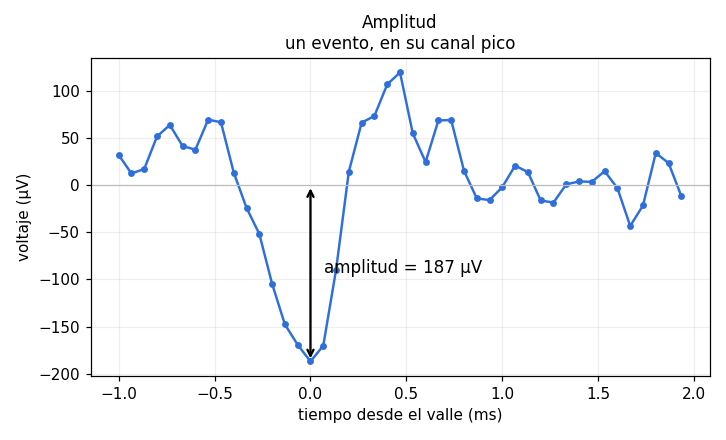

In [ ]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

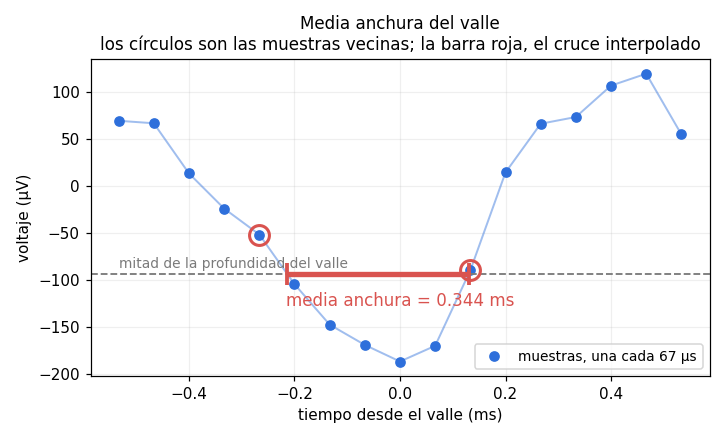

In [ ]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

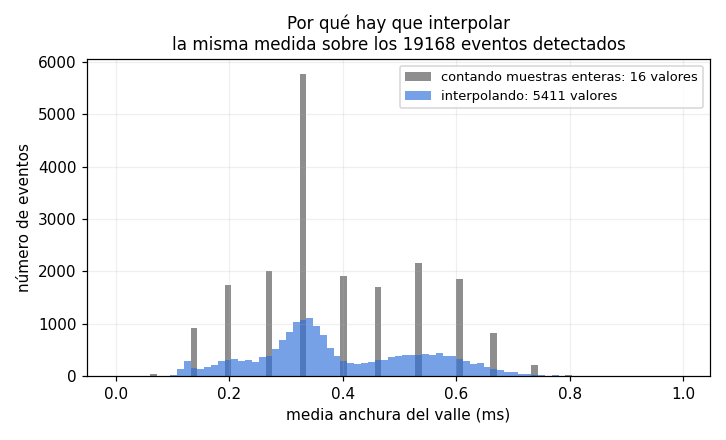

In [ ]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

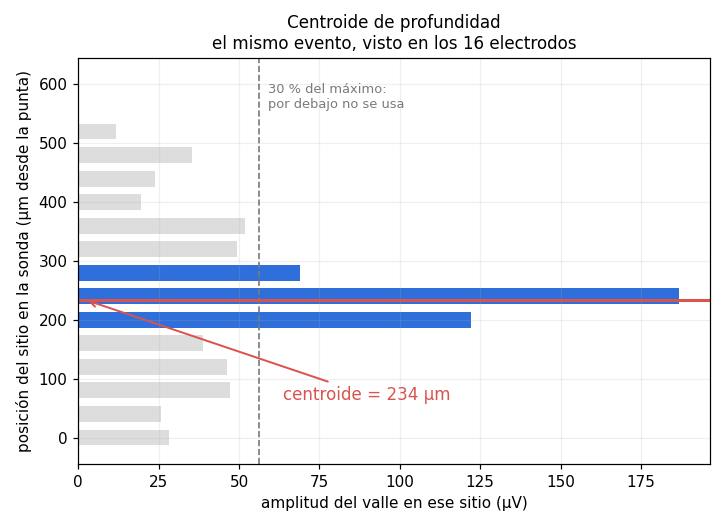

In [ ]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

Forma del arreglo: (2705, 16, 45)
Número de eventos: 2705

Amplitud:
[177.56882503  57.45620523 167.25789298 162.00942789 176.58887817
 191.2740875  164.89569248 215.65607357 160.0225909  183.65651232]

Media anchura del valle:
[0.60917734 0.21621813 0.29193296 0.37305182 0.32884806 0.29850261
 0.34835282 0.33558544 0.30700715 0.5082468 ]

Centroide:
[273.70378884 287.53688271 436.12943103 409.16781353 418.27761432
 410.87599207 407.24654027 221.85861375 400.12101849 523.28893117]


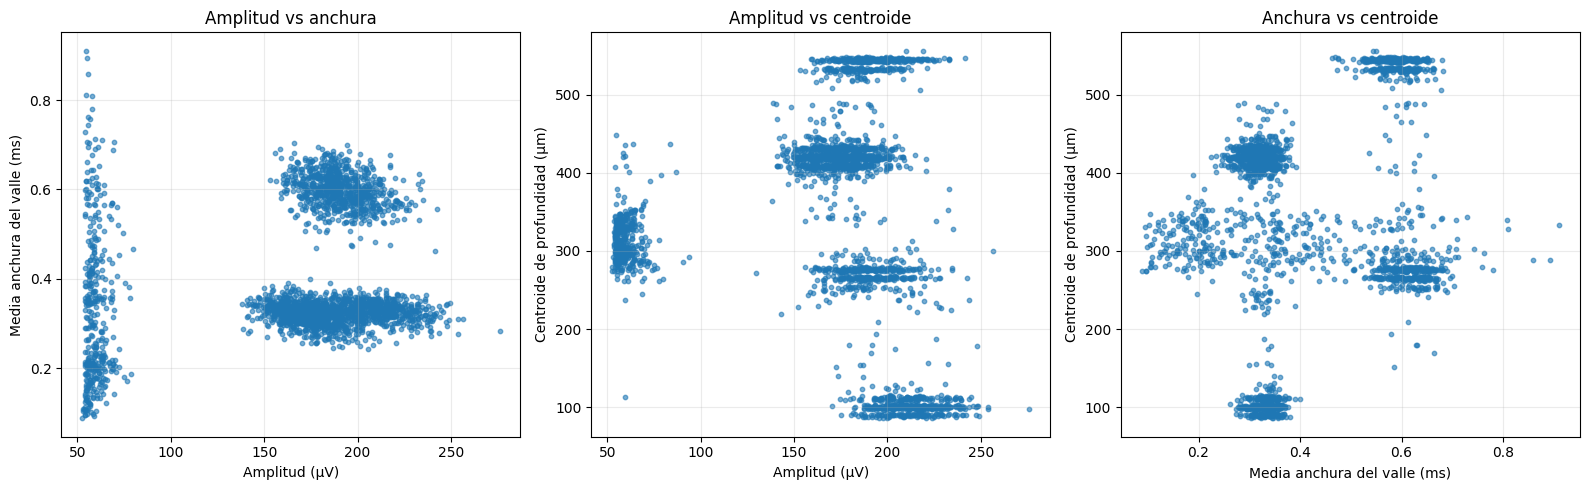

In [ ]:
# ✏️ Ejercicio 3

# ---------- Ejercicio 3.a: extraer formas de onda ----------

def extraer_formas(X, tiempos, canales_pico, fs=15000,
                   pre_ms=1.0, post_ms=2.0):

    pre = int(round(pre_ms / 1000 * fs))
    post = int(round(post_ms / 1000 * fs))

    formas = []
    tiempos_validos = []
    canales_validos = []

    for tiempo, canal in zip(tiempos, canales_pico):

        muestra = int(round(tiempo * fs))

        inicio = muestra - pre
        fin = muestra + post

        # Evitar eventos demasiado cerca de los bordes
        if inicio >= 0 and fin <= X.shape[1]:

            forma = X[:, inicio:fin]

            formas.append(forma)
            tiempos_validos.append(tiempo)
            canales_validos.append(canal)

    return (
        np.array(formas),
        np.array(tiempos_validos),
        np.array(canales_validos)
    )


formas, tiempos, canales_pico = extraer_formas(
    filtrada,
    tiempos_05,
    canales_05,
    fs=fs
)

print("Forma del arreglo:", formas.shape)


# ---------- Media anchura del valle ----------

def media_anchura(onda, fs):

    # Índice y voltaje del valle
    i_min = np.argmin(onda)
    v_min = onda[i_min]

    # Mitad de la profundidad del valle
    mitad = v_min / 2

    # -------- Cruce izquierdo --------
    izquierda = np.nan

    for i in range(i_min - 1, -1, -1):

        if onda[i] > mitad and onda[i + 1] <= mitad:

            # Interpolación lineal
            izquierda = i + (
                (mitad - onda[i]) /
                (onda[i + 1] - onda[i])
            )

            break

    # -------- Cruce derecho --------
    derecha = np.nan

    for i in range(i_min, len(onda) - 1):

        if onda[i] <= mitad and onda[i + 1] > mitad:

            # Interpolación lineal
            derecha = i + (
                (mitad - onda[i]) /
                (onda[i + 1] - onda[i])
            )

            break

    # Si no encontramos alguno de los cruces
    if np.isnan(izquierda) or np.isnan(derecha):
        return np.nan

    # Pasar de muestras a milisegundos
    anchura_ms = (derecha - izquierda) / fs * 1000

    return anchura_ms
# ---------- Ejercicio 3.b: características ----------

def calcular_caracteristicas(formas, canales_pico, profundidad, fs=15000):

    n_eventos = formas.shape[0]

    amplitudes = np.zeros(n_eventos)
    anchuras = np.zeros(n_eventos)
    centroides = np.zeros(n_eventos)

    for e in range(n_eventos):

        forma = formas[e]

        # ----------------------------------
        # 1. Perfil de amplitud
        # ----------------------------------
        # Perfil de amplitud: profundidad del valle en cada canal
        perfil = -np.min(forma, axis=1)

        # Amplitud del evento en su canal pico
        canal = canales_pico[e]
        amplitudes[e] = perfil[canal]


        # ----------------------------------
        # 2. Media anchura del valle
        # ----------------------------------

        canal = canales_pico[e]

        onda_pico = forma[canal]

        anchuras[e] = media_anchura(
            onda_pico,
            fs
        )


        # ----------------------------------
        # 3. Centroide de profundidad
        # ----------------------------------

        maximo = np.max(perfil)

        # Solo canales > 30 % del máximo
        mascara = perfil > 0.30 * maximo

        pesos = perfil[mascara]
        posiciones = profundidad[mascara]

        centroides[e] = (
            np.sum(posiciones * pesos)
            / np.sum(pesos)
        )

    return amplitudes, anchuras, centroides

amplitud, anchura, centroide = calcular_caracteristicas(
    formas,
    canales_pico,
    profundidad,
    fs=fs
)

print("Número de eventos:", len(amplitud))

print("\nAmplitud:")
print(amplitud[:10])

print("\nMedia anchura del valle:")
print(anchura[:10])

print("\nCentroide:")
print(centroide[:10])


# ---------- Ejercicio 3.c: nubes de puntos ----------

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

# 1. Amplitud vs anchura
axes[0].scatter(
    amplitud,
    anchura,
    s=10,
    alpha=0.6
)

axes[0].set_xlabel("Amplitud (µV)")
axes[0].set_ylabel("Media anchura del valle (ms)")
axes[0].set_title("Amplitud vs anchura")


# 2. Amplitud vs centroide
axes[1].scatter(
    amplitud,
    centroide,
    s=10,
    alpha=0.6
)

axes[1].set_xlabel("Amplitud (µV)")
axes[1].set_ylabel("Centroide de profundidad (µm)")
axes[1].set_title("Amplitud vs centroide")


# 3. Anchura vs centroide
axes[2].scatter(
    anchura,
    centroide,
    s=10,
    alpha=0.6
)

axes[2].set_xlabel("Media anchura del valle (ms)")
axes[2].set_ylabel("Centroide de profundidad (µm)")
axes[2].set_title("Anchura vs centroide")


plt.tight_layout()
plt.show()

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario

Respuesta: D

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

*Su respuesta:*

El panel de amplitud vs centroide separa mejor los grupos, porque combina una característica de la intensidad del potencial de acción con una característica espacial de su posición en la sonda. En el panel de amplitud vs anchura algunos grupos con amplitudes de aproximadamente 170–220 µV y anchuras cercanas a 0.3–0.35 ms se superponen, mientras que al incluir el centroide se separan claramente en diferentes profundidades, por ejemplo alrededor de 100 y 420 µm. La anchura vs centroide muestra algunos clusters, pero muchos datos están mezclados en una nube dispersa central

---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


Eventos detectados (después de filtrar NaNs): 18546


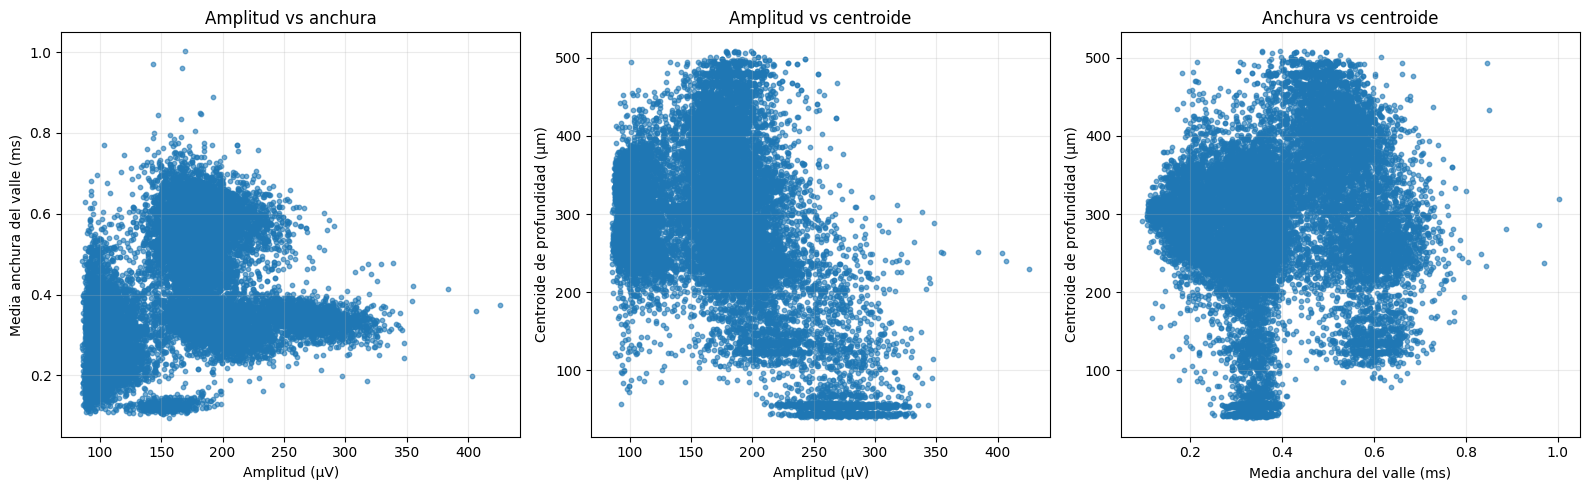

Forma de X estandarizada: (18546, 3)
Media: [ 1.39938985e-14  1.61903753e-14 -9.99200722e-16]
Desviación estándar: [1. 1. 1.]


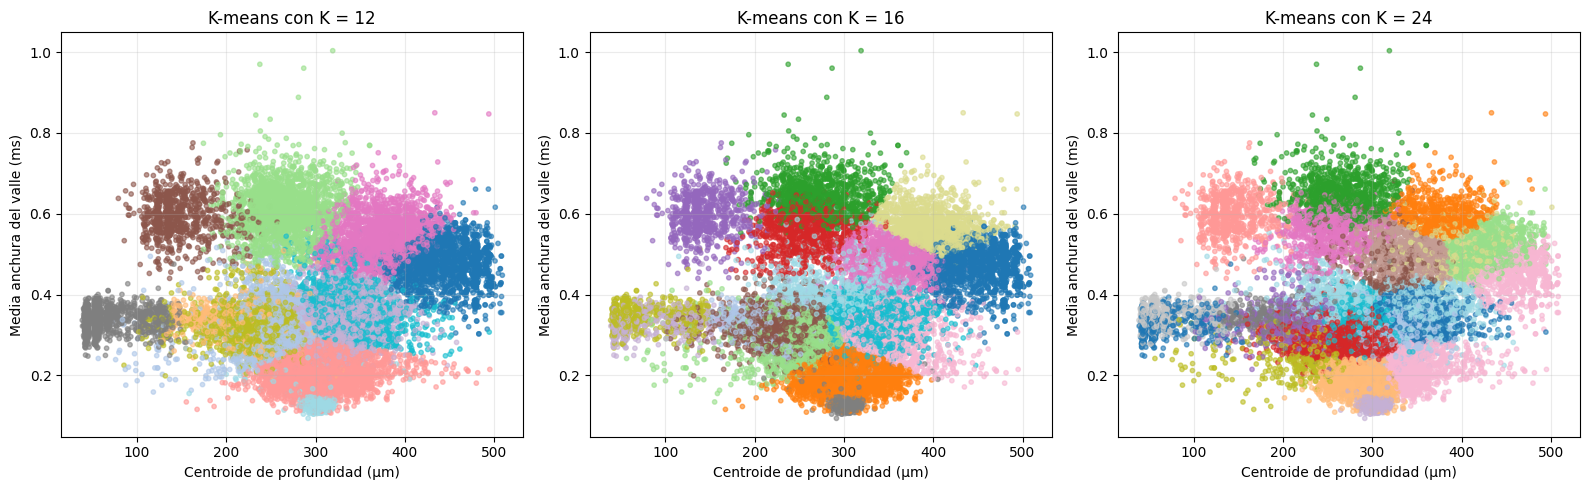

Número de grupos: 24
Eventos agrupados: 18546


In [ ]:
# ✒️ Ejercicio 4

# ============================================================
# a) CORRER EL PIPELINE SOBRE LA GRABACIÓN RUIDOSA
# ============================================================

ARCHIVO = "taller2_ruidosa.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])

    cruda = f["registro/datos"][:].astype(np.float32) * escala
    profundidad = f["geometria/canal_y_um"][:]


# ---------- Filtrado ----------

sos = butter(
    4,
    [300, 5000],
    btype="bandpass",
    fs=fs,
    output="sos"
)

filtrada = sosfiltfilt(
    sos,
    cruda,
    axis=1
)


# ---------- Detección de eventos ----------

tiempos, canales_pico = detectar(
    filtrada,
    k=4.5,
    muerto_ms=0.5,
    fs=fs
)


# ---------- Extraer formas de onda ----------

formas, tiempos, canales_pico = extraer_formas(
    filtrada,
    tiempos,
    canales_pico,
    fs=fs
)


# ---------- Calcular características ----------

amplitud, anchura, centroide = calcular_caracteristicas(
    formas,
    canales_pico,
    profundidad,
    fs=fs
)

# FILTRADO DE NaNs: Eliminar eventos donde alguna característica es NaN
mascara_validos = np.isfinite(amplitud) & np.isfinite(anchura) & np.isfinite(centroide)

# Aplicar la máscara a todas las variables relevantes
amplitud = amplitud[mascara_validos]
anchura = anchura[mascara_validos]
centroide = centroide[mascara_validos]
formas_v = formas[mascara_validos] # formas_v para consistencia con Ejercicio 5
tiempos_v = tiempos[mascara_validos] # tiempos_v para consistencia con Ejercicio 5
perfiles_v = -np.min(
    formas_v,
    axis=2
)

canales_metricas = np.argmax(
    perfiles_v,
    axis=1
)

print(f"Eventos detectados (después de filtrar NaNs): {len(tiempos_v)}")


# ============================================================
# GRAFICAR LAS TRES NUBES
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

# Amplitud vs anchura
axes[0].scatter(
    amplitud,
    anchura,
    s=10,
    alpha=0.6
)

axes[0].set_xlabel("Amplitud (µV)")
axes[0].set_ylabel("Media anchura del valle (ms)")
axes[0].set_title("Amplitud vs anchura")


# Amplitud vs centroide
axes[1].scatter(
    amplitud,
    centroide,
    s=10,
    alpha=0.6
)

axes[1].set_xlabel("Amplitud (µV)")
axes[1].set_ylabel("Centroide de profundidad (µm)")
axes[1].set_title("Amplitud vs centroide")


# Anchura vs centroide
axes[2].scatter(
    anchura,
    centroide,
    s=10,
    alpha=0.6
)

axes[2].set_xlabel("Media anchura del valle (ms)")
axes[2].set_ylabel("Centroide de profundidad (µm)")
axes[2].set_title("Anchura vs centroide")

plt.tight_layout()
plt.show()


# ============================================================
# b) ESTANDARIZAR LAS TRES CARACTERÍSTICAS
# ============================================================

from sklearn.preprocessing import StandardScaler

X_caracteristicas = np.column_stack([
    amplitud,
    anchura,
    centroide
])

mascara_validos = np.isfinite(
    X_caracteristicas
).all(axis=1)

X_caracteristicas_validas = X_caracteristicas[
    mascara_validos
]
scaler = StandardScaler()

X_std = scaler.fit_transform(
    X_caracteristicas_validas
)


print("Forma de X estandarizada:", X_std.shape)
print("Media:", X_std.mean(axis=0))
print("Desviación estándar:", X_std.std(axis=0))


# ============================================================
# c) PROBAR DISTINTOS VALORES DE K
# ============================================================

from sklearn.cluster import KMeans

valores_k = [12, 16, 24]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

for ax, k in zip(axes, valores_k):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas_k = modelo.fit_predict(
        X_std
    )

    # Usamos las características ya filtradas para el plot
    ax.scatter(
        centroide,
        anchura,
        c=etiquetas_k,
        s=10,
        alpha=0.6,
        cmap="tab20"
    )

    ax.set_xlabel(
        "Centroide de profundidad (µm)"
    )

    ax.set_ylabel(
        "Media anchura del valle (ms)"
    )

    ax.set_title(
        f"K-means con K = {k}"
    )

plt.tight_layout()
plt.show()


# ============================================================
# d) ELEGIR K FINAL
# ============================================================

K_ELEGIDO = 24

modelo_final = KMeans(
    n_clusters=K_ELEGIDO,
    random_state=42,
    n_init=10
)

grupos = modelo_final.fit_predict(
    X_std
)


print("Número de grupos:", len(np.unique(grupos)))
print("Eventos agrupados:", len(grupos))

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*
Selección Multiple: B

Abierta: Escogimos K = 24 porque, aunque lleva a la fragmentación de algunos grupos, notamos que un K=16 mantenía fusionados otros grupos que debían estar juntos (y que mas adelante en la verificación nos costaba grupos 'good' marcándolos como noise o mua). Por otra parte, K = 12 un mismo grupo incluye acumulaciones de puntos que parecen estructuras diferentes, fusionando poblaciones. Por último, probamos K más altos (datos no mostrados) que sobrefragmentaban demasiado los grupos, haciendo impráctica su fusión posterior.



---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

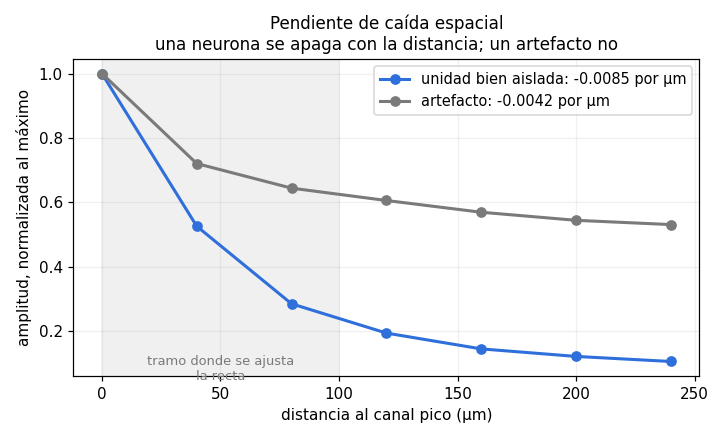

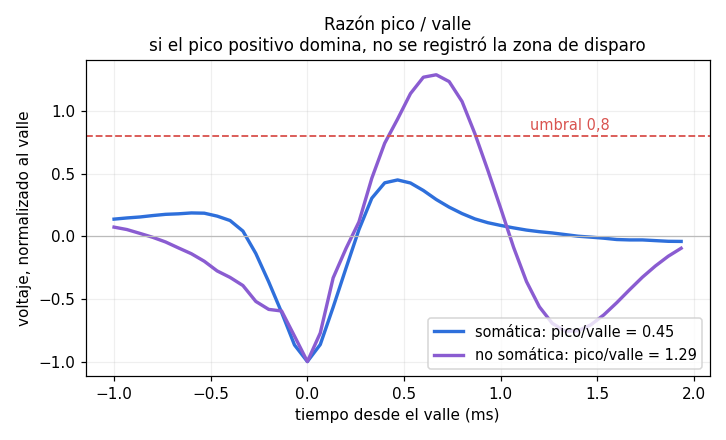

In [ ]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:**

In [ ]:
# ✍️ Ejercicio 5

# ============================================================
# EJERCICIO 5 · MÉTRICAS DE CALIDAD
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import norm


# ============================================================
# 0. PREPARAR LOS DATOS
# ============================================================

# IMPORTANTE:
# "grupos" ya viene del punto 4 con K = 20.
# NO volvemos a correr K-means.

# Las variables formas_v, tiempos_v, canales_v y amplitud_v
# ya están correctamente filtradas y asignadas en la celda anterior (Ejercicio 4)
# para asegurar la consistencia con este Ejercicio 5.
# Por lo tanto, las siguientes líneas son redundantes y causan un error.
# # Aplicamos la misma máscara usada en P4
# formas_v = formas[mascara_validos]
# tiempos_v = tiempos[mascara_validos]

# # Este es el canal pico que salió del detector.
# # Lo conservamos porque después se usa para verificar detección.
# canales_v = canales_pico[mascara_validos]

# amplitud_v = amplitud[mascara_validos]


# ------------------------------------------------------------
# Canal pico PARA LAS MÉTRICAS
# ------------------------------------------------------------
# Para cada evento calculamos la profundidad del valle
# en cada uno de los 16 canales.
#
# formas_v:
# eventos × canales × tiempo
#
# perfiles_v:
# eventos × canales

perfiles_v = -np.min(
    formas_v,
    axis=2
)

# Canal donde el valle es más profundo en cada evento
canales_metricas = np.argmax(
    perfiles_v,
    axis=1
)


# Revisar que todo esté alineado
print("Eventos usados:", len(grupos))
print("Formas válidas:", len(formas_v))
print("Tiempos válidos:", len(tiempos_v))
print("Amplitudes válidas:", len(amplitud))

assert len(grupos) == len(formas_v)
assert len(grupos) == len(tiempos_v)
assert len(grupos) == len(amplitud)
assert len(grupos) == len(canales_metricas)


# ============================================================
# 1. FUNCIÓN PARA ESTIMAR DISPAROS FALTANTES
# ============================================================

def estimar_faltantes(amplitudes, umbral_amp):

    amplitudes = np.asarray(
        amplitudes,
        dtype=float
    )

    # Eliminar valores no válidos
    amplitudes = amplitudes[
        np.isfinite(amplitudes)
    ]

    # Muy pocos disparos -> ajuste no confiable
    if len(amplitudes) < 10:
        return np.nan


    # --------------------------------------------------------
    # Histograma de amplitudes
    # --------------------------------------------------------

    hist, bordes = np.histogram(
        amplitudes,
        bins="auto"
    )

    centros = (
        bordes[:-1]
        + bordes[1:]
    ) / 2


    # --------------------------------------------------------
    # Encontrar el pico del histograma
    # --------------------------------------------------------

    i_pico = np.argmax(hist)

    mu = centros[i_pico]


    # --------------------------------------------------------
    # Usar SOLO la mitad derecha de la distribución
    # --------------------------------------------------------

    mascara_derecha = (
        centros >= mu
    )

    x = centros[
        mascara_derecha
    ]

    y = hist[
        mascara_derecha
    ]


    if (
        len(x) < 3
        or np.max(y) == 0
    ):
        return np.nan


    # --------------------------------------------------------
    # Campana gaussiana
    # --------------------------------------------------------

    # El centro se fija en el pico del histograma.
    # Ajustamos altura y sigma.

    def gaussiana(x, A, sigma):

        return A * np.exp(
            -0.5
            * ((x - mu) / sigma)**2
        )


    sigma0 = np.std(
        amplitudes
    )

    if (
        not np.isfinite(sigma0)
        or sigma0 <= 0
    ):
        return np.nan


    try:

        parametros, _ = curve_fit(

            gaussiana,

            x,
            y,

            p0=[
                hist[i_pico],
                sigma0
            ],

            bounds=(
                [0, 1e-6],
                [np.inf, np.inf]
            ),

            maxfev=10000
        )


        sigma = parametros[1]


        # Fracción de la campana ajustada
        # que estaría por debajo del umbral

        porcentaje = (
            100
            * norm.cdf(
                umbral_amp,
                loc=mu,
                scale=sigma
            )
        )


        return float(
            np.clip(
                porcentaje,
                0,
                100
            )
        )


    except (
        RuntimeError,
        ValueError,
        FloatingPointError
    ):
        pass

    # FALLBACK

    if len(valores_derecha) < 3:
        return np.nan

    sigma_fallback = np.std(
        valores_derecha
    )

    porcentaje_fallback = (
        100
        * norm.cdf(
            umbral_amp,
            loc=mu,
            scale=sigma_fallback
        )
    )

    return float(
        np.clip(
            porcentaje_fallback,
            0,
            100
        )
    )

# ============================================================
# 2. FUNCIÓN PARA CALCULAR LAS 7 MÉTRICAS
# ============================================================

def calcular_metricas_grupos(
    formas,
    tiempos,
    canales_metricas,
    amplitudes,
    grupos,
    profundidad,
    filtrada,
    fs=15000,
    k_umbral=4.5
):

    resultados = []


    # ========================================================
    # UMBRAL DE DETECCIÓN POR CANAL
    # ========================================================

    sigma_ruido = (
        np.median(
            np.abs(filtrada),
            axis=1
        )
        / 0.6745
    )

    umbral_amp_canal = (
        k_umbral
        * sigma_ruido
    )


    # ========================================================
    # RECORRER LOS 16 GRUPOS
    # ========================================================

    for grupo in np.unique(grupos):

        idx = np.where(
            grupos == grupo
        )[0]

        n_disparos = len(idx)


        # ====================================================
        # FORMA DE ONDA PROMEDIO
        # ====================================================

        # Para cada evento usamos SU propio canal pico
        ondas_pico = formas[
            idx,
            canales_metricas[idx],
            :
        ]

        onda_promedio = np.mean(
            ondas_pico,
            axis=0
        )


        # ====================================================
        # 1. NÚMERO DE PICOS Y VALLES
        # ====================================================

        rango = np.ptp(
            onda_promedio
        )

        # Evitar que pequeñas oscilaciones de ruido
        # cuenten como picos reales

        prominencia = (
            0.10 * rango
            if rango > 0
            else 0
        )


        picos, _ = find_peaks(
            onda_promedio,
            prominence=prominencia
        )

        valles, _ = find_peaks(
            -onda_promedio,
            prominence=prominencia
        )


        n_picos = len(picos)
        n_valles = len(valles)


        # ====================================================
        # 2. DURACIÓN VALLE → PICO DE REPOLARIZACIÓN
        # ====================================================

        i_valle = np.argmin(
            onda_promedio
        )


        # Picos POSITIVOS después del valle

        picos_despues = picos[
            (picos > i_valle)
            &
            (onda_promedio[picos] > 0)
        ]


        if len(picos_despues) > 0:

            # Pico positivo más alto

            i_pico = picos_despues[
                np.argmax(
                    onda_promedio[
                        picos_despues
                    ]
                )
            ]


            duracion_us = (
                (i_pico - i_valle)
                / fs
                * 1e6
            )

        else:

            duracion_us = np.nan


        # ====================================================
        # 3. PENDIENTE DE CAÍDA ESPACIAL
        # ====================================================

        distancias_total = []
        amplitudes_norm_total = []


        for i in idx:

            # Amplitud del valle en cada canal

            perfil = -np.min(
                formas[i],
                axis=1
            )


            # Canal pico REAL de este evento

            canal = canales_metricas[i]

            maximo = perfil[canal]


            if (
                not np.isfinite(maximo)
                or maximo <= 0
            ):
                continue


            # Normalizar amplitudes
            # por el máximo de ESTE evento

            perfil_norm = (
                perfil
                / maximo
            )


            # Distancia de cada sitio
            # respecto al canal pico

            distancias = np.abs(
                profundidad
                - profundidad[canal]
            )


            # Sólo distancias <= 100 µm

            mascara_100 = (
                (distancias <= 100)
                &
                np.isfinite(
                    perfil_norm
                )
            )


            distancias_total.extend(
                distancias[
                    mascara_100
                ]
            )

            amplitudes_norm_total.extend(
                perfil_norm[
                    mascara_100
                ]
            )


        distancias_total = np.asarray(
            distancias_total,
            dtype=float
        )

        amplitudes_norm_total = np.asarray(
            amplitudes_norm_total,
            dtype=float
        )


        if len(distancias_total) >= 2:

            pendiente = np.polyfit(
                distancias_total,
                amplitudes_norm_total,
                1
            )[0]

        else:

            pendiente = np.nan


        # ====================================================
        # 4. RAZÓN PICO / VALLE
        # ====================================================

        profundidad_valle = abs(
            np.min(
                onda_promedio
            )
        )


        pico_positivo = max(
            np.max(
                onda_promedio
            ),
            0
        )


        if profundidad_valle > 0:

            razon_pico_valle = (
                pico_positivo
                / profundidad_valle
            )

        else:

            razon_pico_valle = np.nan


        # ====================================================
        # 5. VIOLACIONES DEL PERÍODO REFRACTARIO
        # ====================================================

        tiempos_grupo = np.sort(
            tiempos[idx]
        )

        isi = np.diff(
            tiempos_grupo
        )


        if len(isi) > 0:

            porcentaje_refractario = (
                100
                * np.mean(
                    isi < 0.002
                )
            )

        else:

            porcentaje_refractario = np.nan


        # ====================================================
        # 6. DISPAROS FALTANTES
        # ====================================================

        amps_grupo = amplitudes[
            idx
        ]


        # Umbral típico de los canales donde
        # realmente está el máximo de cada evento

        umbral_grupo = np.median(

            umbral_amp_canal[
                canales_metricas[idx]
            ]
        )


        porcentaje_faltantes = (
            estimar_faltantes(
                amps_grupo,
                umbral_grupo
            )
        )


        # ====================================================
        # 7. NÚMERO DE DISPAROS
        # ====================================================

        # n_disparos ya está calculado


        # ====================================================
        # GUARDAR RESULTADOS
        # ====================================================

        resultados.append({

            "grupo":
                int(grupo),

            "picos":
                n_picos,

            "valles":
                n_valles,

            "duracion_us":
                duracion_us,

            "pendiente":
                pendiente,

            "razon_pico_valle":
                razon_pico_valle,

            "refractario_%":
                porcentaje_refractario,

            "faltantes_%":
                porcentaje_faltantes,

            "n_disparos":
                n_disparos

        })


    return pd.DataFrame(
        resultados
    )


# ============================================================
# 3. CALCULAR TABLA
# ============================================================

tabla_metricas = calcular_metricas_grupos(

    formas=formas_v,

    tiempos=tiempos_v,

    canales_metricas=
        canales_metricas,

    amplitudes=amplitud,

    grupos=grupos,

    profundidad=profundidad,

    filtrada=filtrada,

    fs=fs,

    k_umbral=4.5
)


tabla_metricas = (
    tabla_metricas
    .sort_values("grupo")
    .reset_index(drop=True)
)


display(

    tabla_metricas.round({

        "duracion_us": 1,

        "pendiente": 5,

        "razon_pico_valle": 3,

        "refractario_%": 2,

        "faltantes_%": 2
    })
)

# ============================================================
# 4. IDENTIFICAR DISTRIBUCIONES CORTADAS
# ============================================================

grupos_cortados = (

    tabla_metricas.loc[
        tabla_metricas["faltantes_%"] >= 20,
        "grupo"
    ]

    .astype(int)

    .tolist()
)


print(
    "Grupos con >= 20% de disparos faltantes:",
    grupos_cortados
)


Eventos usados: 18546
Formas válidas: 18546
Tiempos válidos: 18546
Amplitudes válidas: 18546


,grupo,picos,valles,duracion_us,pendiente,razon_pico_valle,refractario_%,faltantes_%,n_disparos
0,0,1,1,466.7,-0.00844,0.466,0.00,0.00,637
1,1,1,1,600.0,-0.00499,0.384,0.88,32.77,1028
2,2,1,1,533.3,-0.00728,0.438,1.18,0.00,847
3,3,1,1,866.7,-0.00664,0.578,4.48,0.00,783
4,4,1,1,600.0,-0.00435,0.295,0.52,42.47,1159
5,5,1,1,933.3,-0.00683,0.645,0.40,0.00,1006
6,6,2,1,733.3,-0.00711,0.568,17.16,0.00,1038
7,7,1,1,533.3,-0.00416,0.386,0.74,27.60,952
8,8,1,1,466.7,-0.00777,0.448,0.23,0.00,882
9,9,1,1,933.3,-0.00758,0.627,0.42,0.00,721


Grupos con >= 20% de disparos faltantes: [1, 4, 7, 12, 16, 22]


**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia
- **d)** una unidad no somática

Respuesta: C

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

Los grupos 1, 4, 7, 12, 16 y 22 presentan una distribución de amplitudes cortada por el umbral de detección, con porcentajes estimados de disparos faltantes de 32.77 %, 42.47 %, 27.60 %, 32.19%, 41.38% y 38.17%, respectivamente. Para ilustrarlo, comparamos el grupo 16 con el grupo 5, cuya estimación de disparos faltantes es aproximadamente 0 %.

En el grupo 16, las amplitudes más pequeñas quedan por debajo del umbral y, por tanto, esos potenciales de acción no son detectados. Esto explica el alto porcentaje de disparos faltantes. En cambio, en el grupo 5 la distribución no presenta un corte importante y prácticamente todos los disparos esperados son detectados.

Como consecuencia, la tasa de disparo observada del grupo 16 subestima la tasa de disparo real, porque una fracción considerable de sus potenciales de acción no fue registrada. En el grupo 5, la tasa observada debería ser mucho más cercana a la tasa real.

En el histograma (abajo) se observa que la distribución de amplitudes termina abruptamente cerca del umbral. La cola de bajas amplitudes se corta porque están por debajo del umbral y los eventos correspondientes no son detectados. Como ya se dijo, esto significa que la tasa de disparo observada sea menor que la real.

,grupo,faltantes_%,n_disparos
4,4,42.47,1159
16,16,41.38,922
22,22,38.17,692
1,1,32.77,1028
12,12,32.19,321
7,7,27.60,952
19,19,0.95,453
11,11,0.00,473
14,14,0.00,941
15,15,0.00,735


Grupos con distribución de amplitudes cortada: [1, 4, 7, 12, 16, 22]
Grupos sin distribución de amplitudes cortada: [0, 2, 3, 5, 6, 8, 9, 10, 11, 13, 14, 15, 17, 19, 20, 21, 23]

Grupo 16:
  Disparos = 922
  Faltantes estimados = 41.38%
  Umbral = 88.65 µV

Grupo 5:
  Disparos = 1006
  Faltantes estimados = 0.00%
  Umbral = 93.69 µV


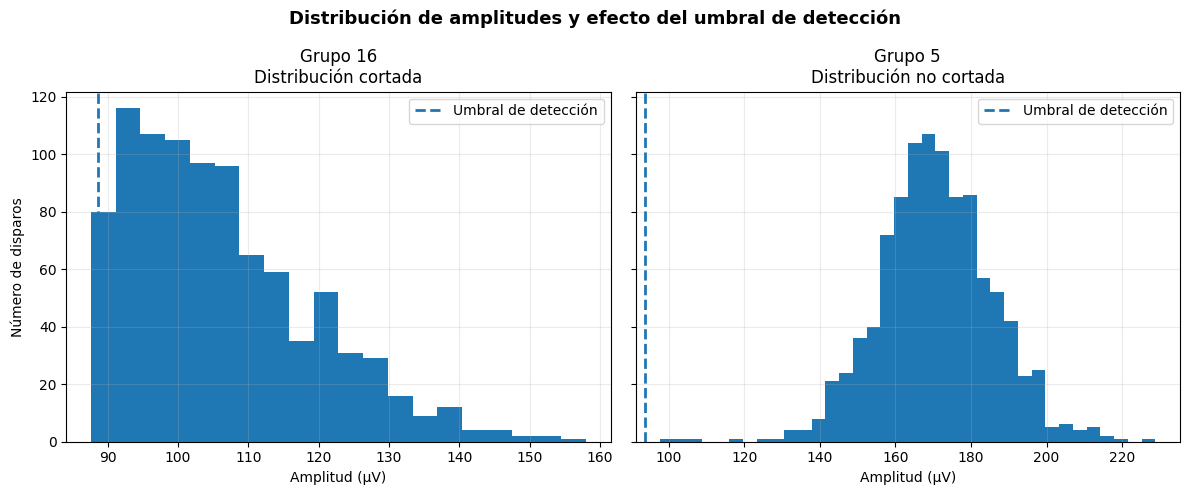

In [ ]:
# ============================================================
# DISTRIBUCIÓN DE AMPLITUDES:
# GRUPO CON DISTRIBUCIÓN CORTADA VS GRUPO SANO
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. MOSTRAR LA TABLA RELEVANTE
# ============================================================

tabla_amplitudes = tabla_metricas[
    [
        "grupo",
        "faltantes_%",
        "n_disparos"
    ]
].sort_values(
    "faltantes_%",
    ascending=False
)

display(
    tabla_amplitudes.round({
        "faltantes_%": 2
    })
)


# ============================================================
# 2. IDENTIFICAR AUTOMÁTICAMENTE LOS GRUPOS CORTADOS
# ============================================================

grupos_cortados = (
    tabla_metricas.loc[
        tabla_metricas["faltantes_%"] >= 20,
        "grupo"
    ]
    .astype(int)
    .tolist()
)

print(
    "Grupos con distribución de amplitudes cortada:",
    grupos_cortados
)


# ============================================================
# 3. IDENTIFICAR GRUPOS SANOS
# ============================================================

grupos_sanos = (
    tabla_metricas.loc[
        tabla_metricas["faltantes_%"] < 20,
        "grupo"
    ]
    .astype(int)
    .tolist()
)

print(
    "Grupos sin distribución de amplitudes cortada:",
    grupos_sanos
)


# ============================================================
# 4. ELEGIR LOS DOS GRUPOS A COMPARAR
# ============================================================

# ============================================================
# INGRESA AQUÍ LOS NÚMEROS DE LOS DOS GRUPOS A COMPARAR
# GRUPO_CORTADO = GRUPO CON DISTRIBUCIÓN CORTADA
# GRUPO_SANO = GRUPO PARA COMPARAR
# ============================================================

GRUPO_CORTADO = 16
GRUPO_SANO = 5


# ============================================================
# 5. COMPROBAR QUE LA ELECCIÓN SEA COHERENTE
# ============================================================

if GRUPO_CORTADO not in grupos_cortados:
    print(
        f"ADVERTENCIA: el grupo {GRUPO_CORTADO} "
        "no tiene faltantes_% >= 20."
    )

if GRUPO_SANO not in grupos_sanos:
    print(
        f"ADVERTENCIA: el grupo {GRUPO_SANO} "
        "tiene faltantes_% >= 20."
    )


# ============================================================
# 6. UMBRAL DE DETECCIÓN POR CANAL
# ============================================================

sigma_ruido = (
    np.median(
        np.abs(filtrada),
        axis=1
    )
    / 0.6745
)

umbral_amp_canal = (
    4.5 * sigma_ruido
)


# ============================================================
# 7. FUNCIÓN PARA OBTENER EL UMBRAL DEL GRUPO
# ============================================================

def umbral_grupo_amplitud(grupo):

    idx = np.where(
        grupos == grupo
    )[0]

    return np.median(
        umbral_amp_canal[
            canales_metricas[idx]
        ]
    )


# ============================================================
# 8. OBTENER LOS EVENTOS DE CADA GRUPO
# ============================================================

idx_cortado = np.where(
    grupos == GRUPO_CORTADO
)[0]

idx_sano = np.where(
    grupos == GRUPO_SANO
)[0]


# ============================================================
# 9. OBTENER LAS AMPLITUDES
# ============================================================

amplitudes_cortado = amplitud[
    idx_cortado
]

amplitudes_sano = amplitud[
    idx_sano
]


# ============================================================
# 10. OBTENER LOS UMBRALES
# ============================================================

umbral_cortado = (
    umbral_grupo_amplitud(
        GRUPO_CORTADO
    )
)

umbral_sano = (
    umbral_grupo_amplitud(
        GRUPO_SANO
    )
)


# ============================================================
# 11. MOSTRAR INFORMACIÓN DE LOS DOS GRUPOS
# ============================================================

faltantes_cortado = (
    tabla_metricas.loc[
        tabla_metricas["grupo"] == GRUPO_CORTADO,
        "faltantes_%"
    ].iloc[0]
)

faltantes_sano = (
    tabla_metricas.loc[
        tabla_metricas["grupo"] == GRUPO_SANO,
        "faltantes_%"
    ].iloc[0]
)

print(
    f"\nGrupo {GRUPO_CORTADO}:"
)

print(
    f"  Disparos = {len(amplitudes_cortado)}"
)

print(
    f"  Faltantes estimados = "
    f"{faltantes_cortado:.2f}%"
)

print(
    f"  Umbral = {umbral_cortado:.2f} µV"
)


print(
    f"\nGrupo {GRUPO_SANO}:"
)

print(
    f"  Disparos = {len(amplitudes_sano)}"
)

print(
    f"  Faltantes estimados = "
    f"{faltantes_sano:.2f}%"
)

print(
    f"  Umbral = {umbral_sano:.2f} µV"
)


# ============================================================
# 12. GRAFICAR LOS DOS HISTOGRAMAS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharey=True
)


# ============================================================
# GRUPO CORTADO
# ============================================================

axes[0].hist(
    amplitudes_cortado,
    bins="auto"
)

axes[0].axvline(
    umbral_cortado,
    linestyle="--",
    linewidth=2,
    label="Umbral de detección"
)

axes[0].set_title(
    f"Grupo {GRUPO_CORTADO}\n"
    f"Distribución cortada"
)

axes[0].set_xlabel(
    "Amplitud (µV)"
)

axes[0].set_ylabel(
    "Número de disparos"
)

axes[0].legend()


# ============================================================
# GRUPO SANO
# ============================================================

axes[1].hist(
    amplitudes_sano,
    bins="auto"
)

axes[1].axvline(
    umbral_sano,
    linestyle="--",
    linewidth=2,
    label="Umbral de detección"
)

axes[1].set_title(
    f"Grupo {GRUPO_SANO}\n"
    f"Distribución no cortada"
)

axes[1].set_xlabel(
    "Amplitud (µV)"
)

axes[1].legend()


# ============================================================
# FORMATO FINAL
# ============================================================

fig.suptitle(
    "Distribución de amplitudes y efecto del umbral de detección",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

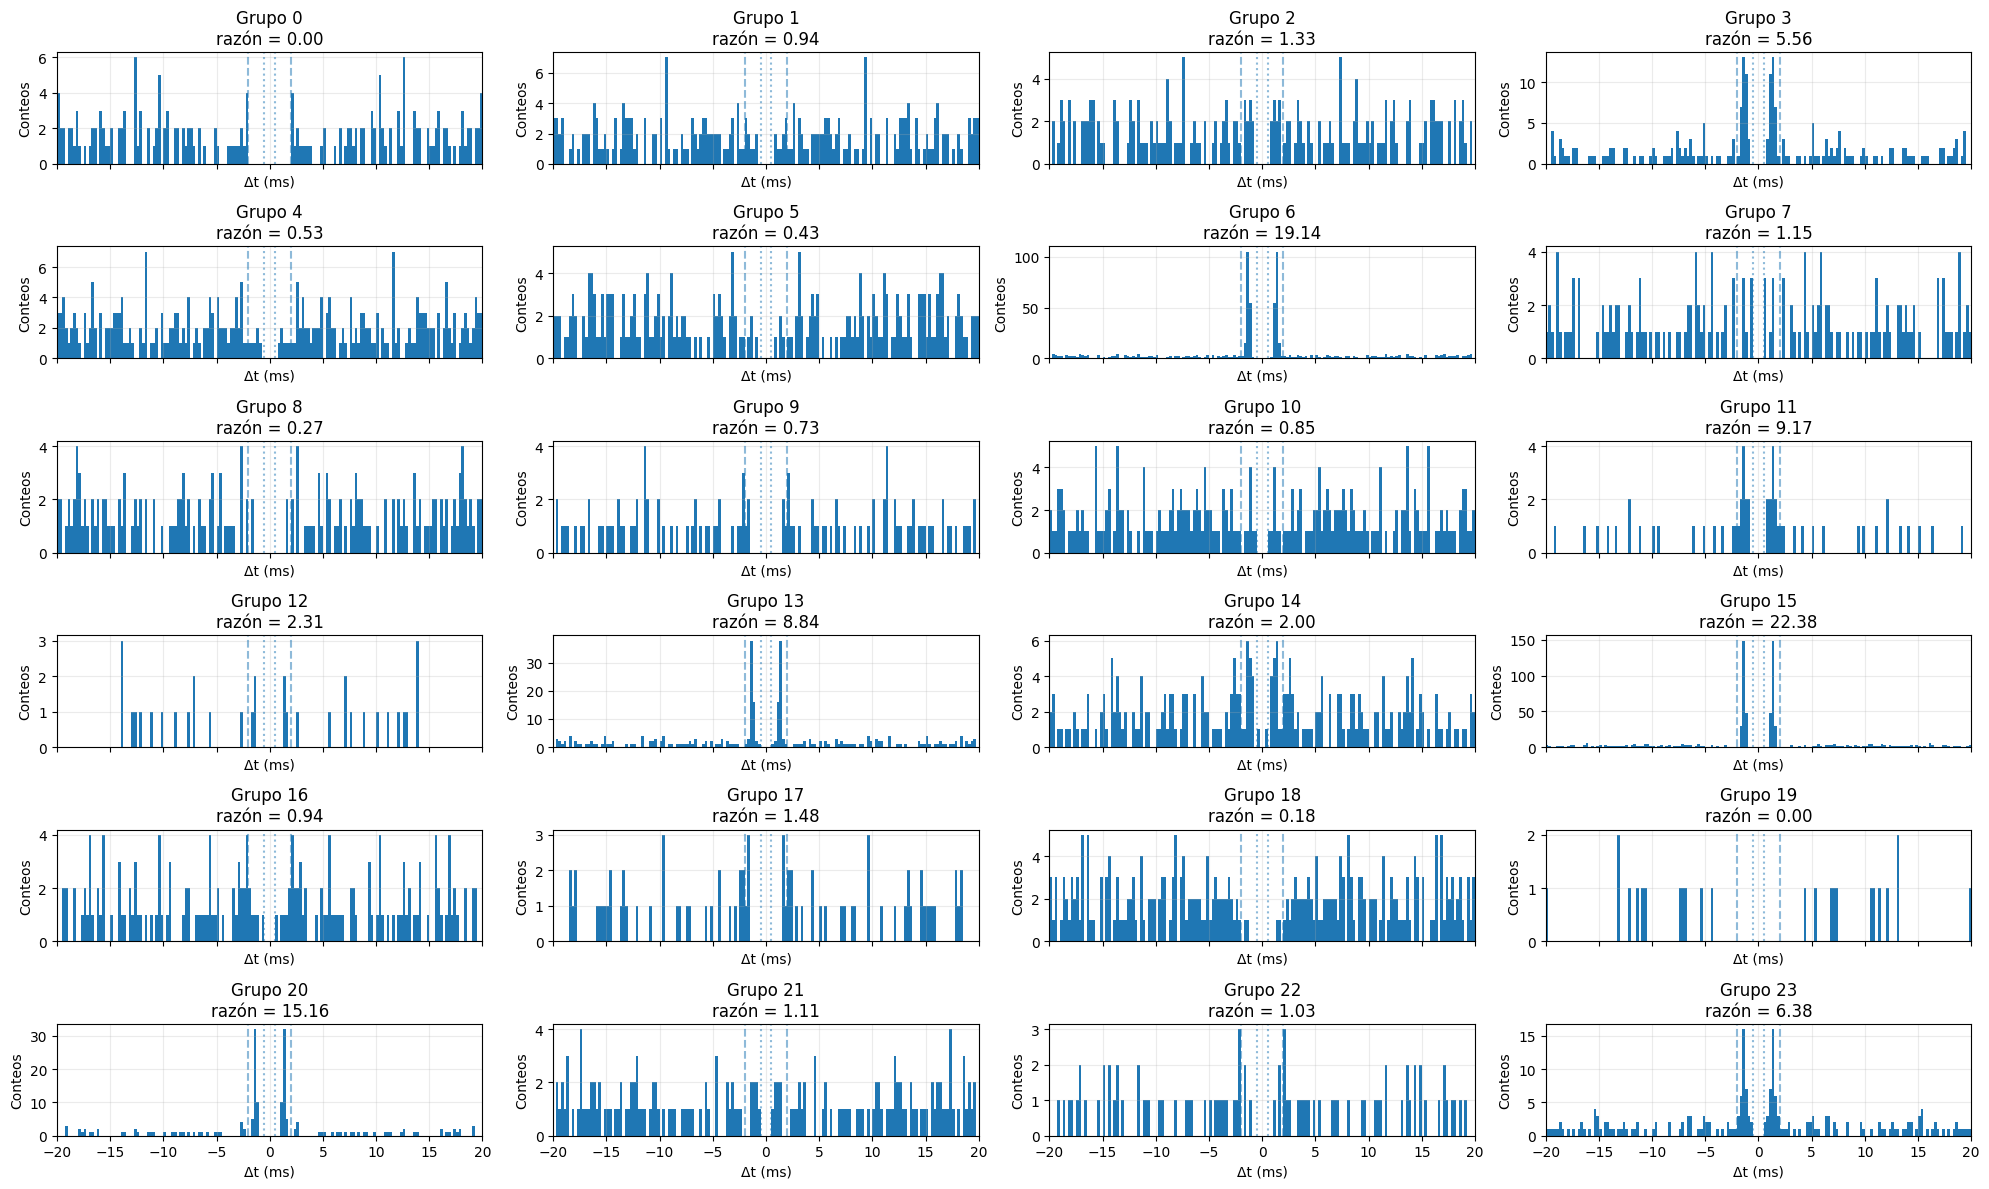

10 parejas más cercanas:
Grupos 8 y 10 -> distancia = 0.614
Grupos 6 y 20 -> distancia = 0.694
Grupos 6 y 15 -> distancia = 0.713
Grupos 7 y 22 -> distancia = 0.715
Grupos 4 y 16 -> distancia = 0.727
Grupos 1 y 7 -> distancia = 0.729
Grupos 2 y 23 -> distancia = 0.729
Grupos 3 y 6 -> distancia = 0.743
Grupos 10 y 21 -> distancia = 0.744
Grupos 0 y 18 -> distancia = 0.755

Parejas candidatas a ser la misma neurona:

Grupos 10 y 21 | distancia = 0.744 | razón = 0.076
Grupos 4 y 16 | distancia = 0.727 | razón = 0.185
Grupos 8 y 10 | distancia = 0.614 | razón = 0.288
Grupos 4 y 19 | distancia = 0.902 | razón = 0.290
Grupos 5 y 14 | distancia = 0.782 | razón = 0.317
Grupos 7 y 19 | distancia = 0.830 | razón = 0.323
Grupos 12 y 22 | distancia = 0.963 | razón = 0.345
Grupos 0 y 18 | distancia = 0.755 | razón = 0.402
Grupos 1 y 7 | distancia = 0.729 | razón = 0.423
Grupos 2 y 8 | distancia = 0.946 | razón = 0.423
Grupos 7 y 16 | distancia = 0.877 | razón = 0.530
Grupos 2 y 21 | distancia = 0.7

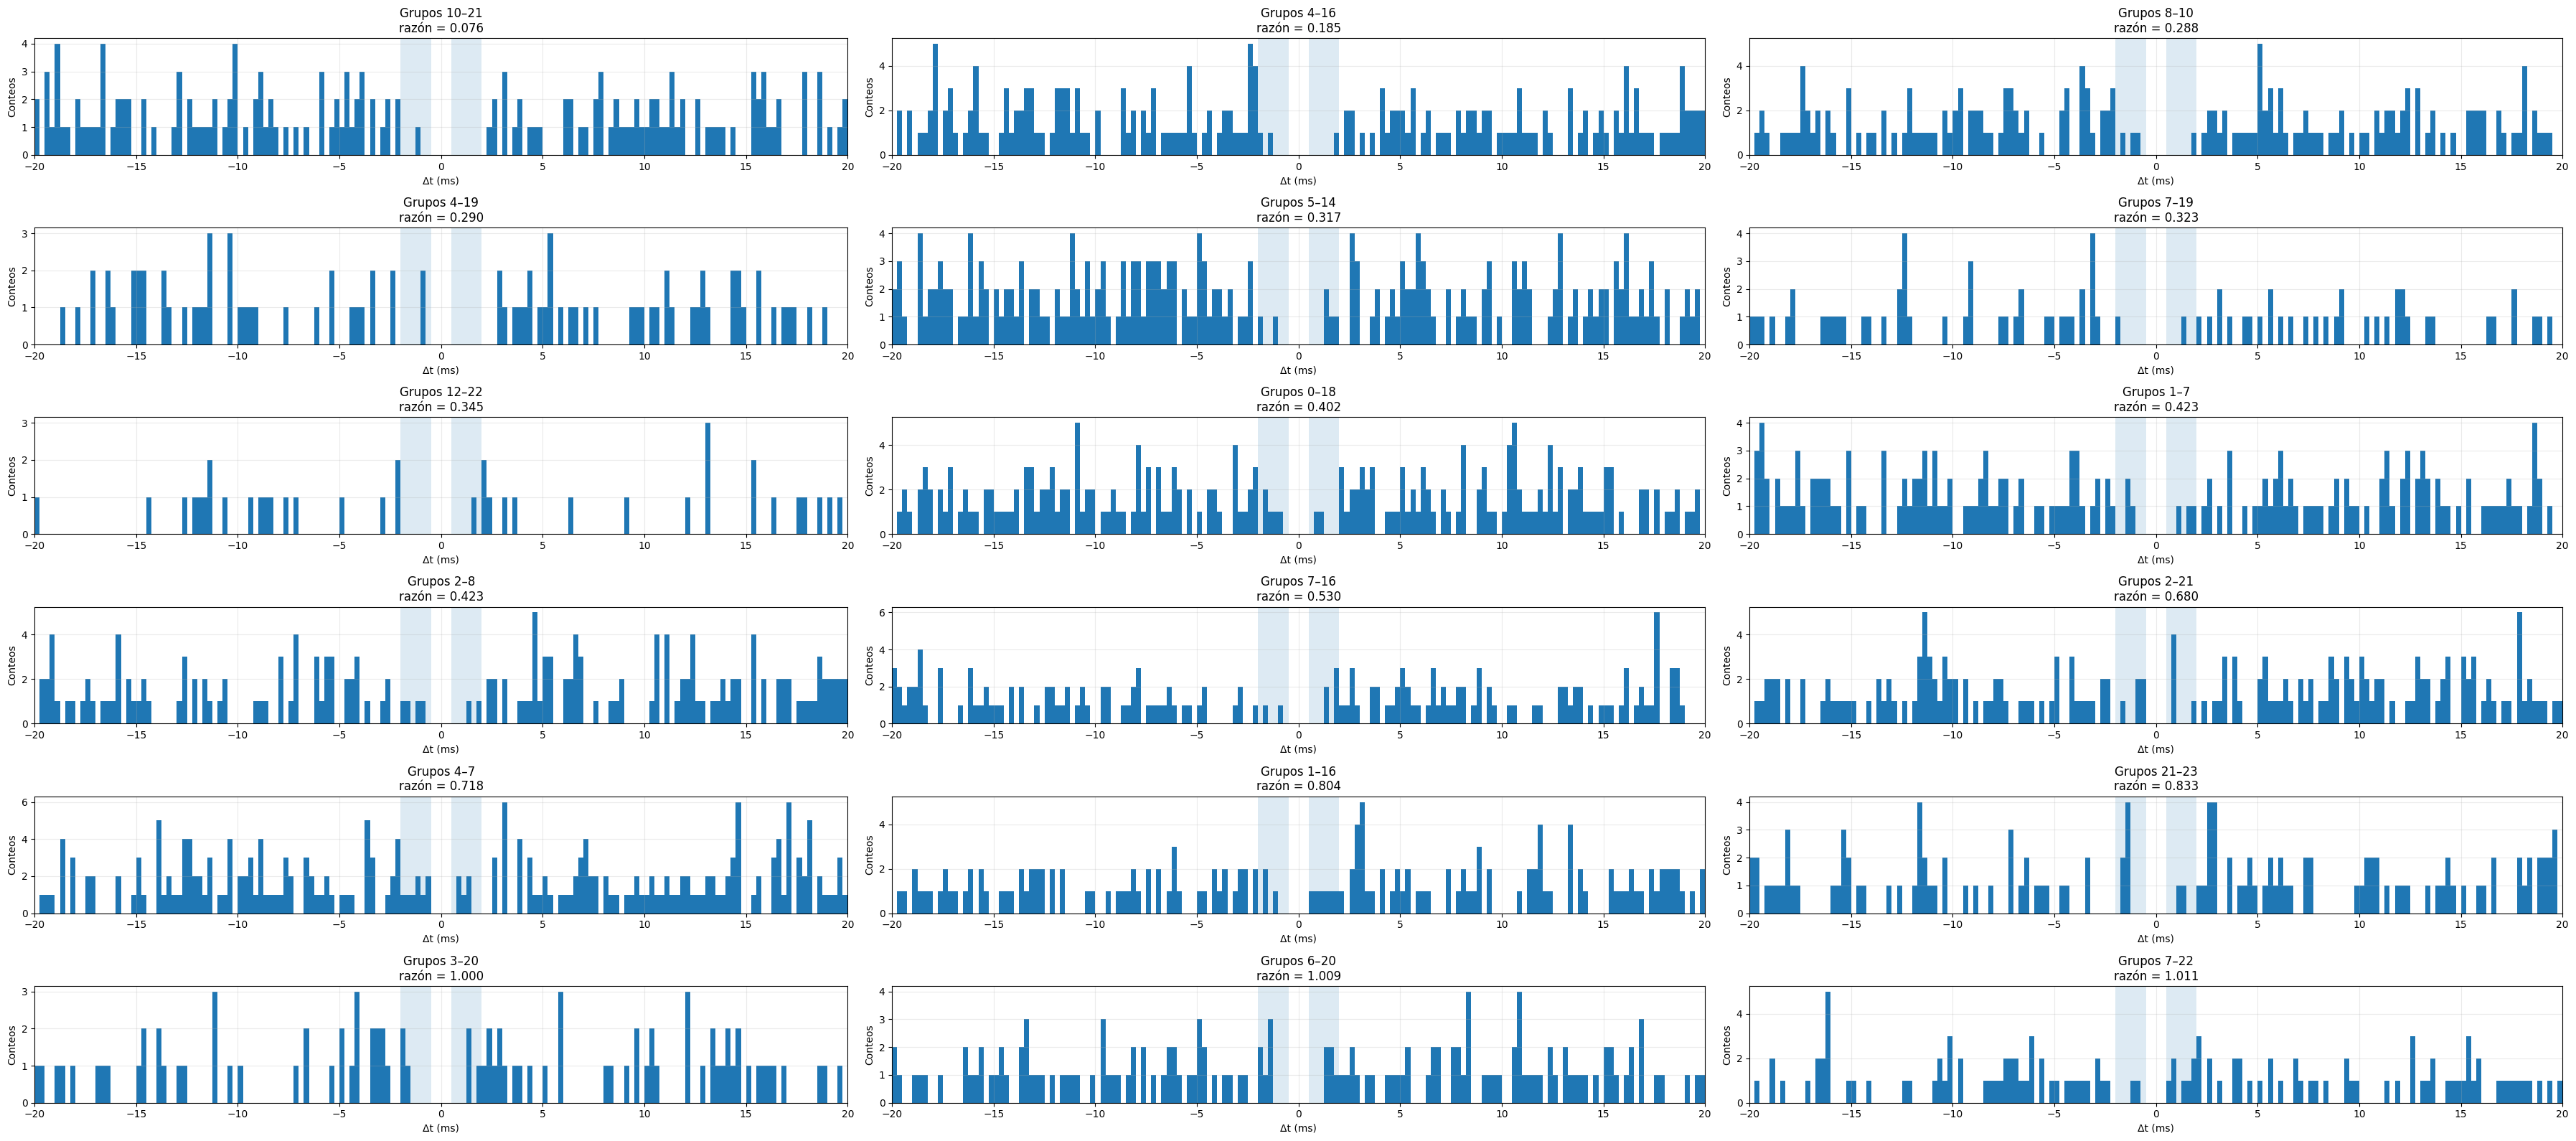

/tmp/ipykernel_19672/2273748005.py:457: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


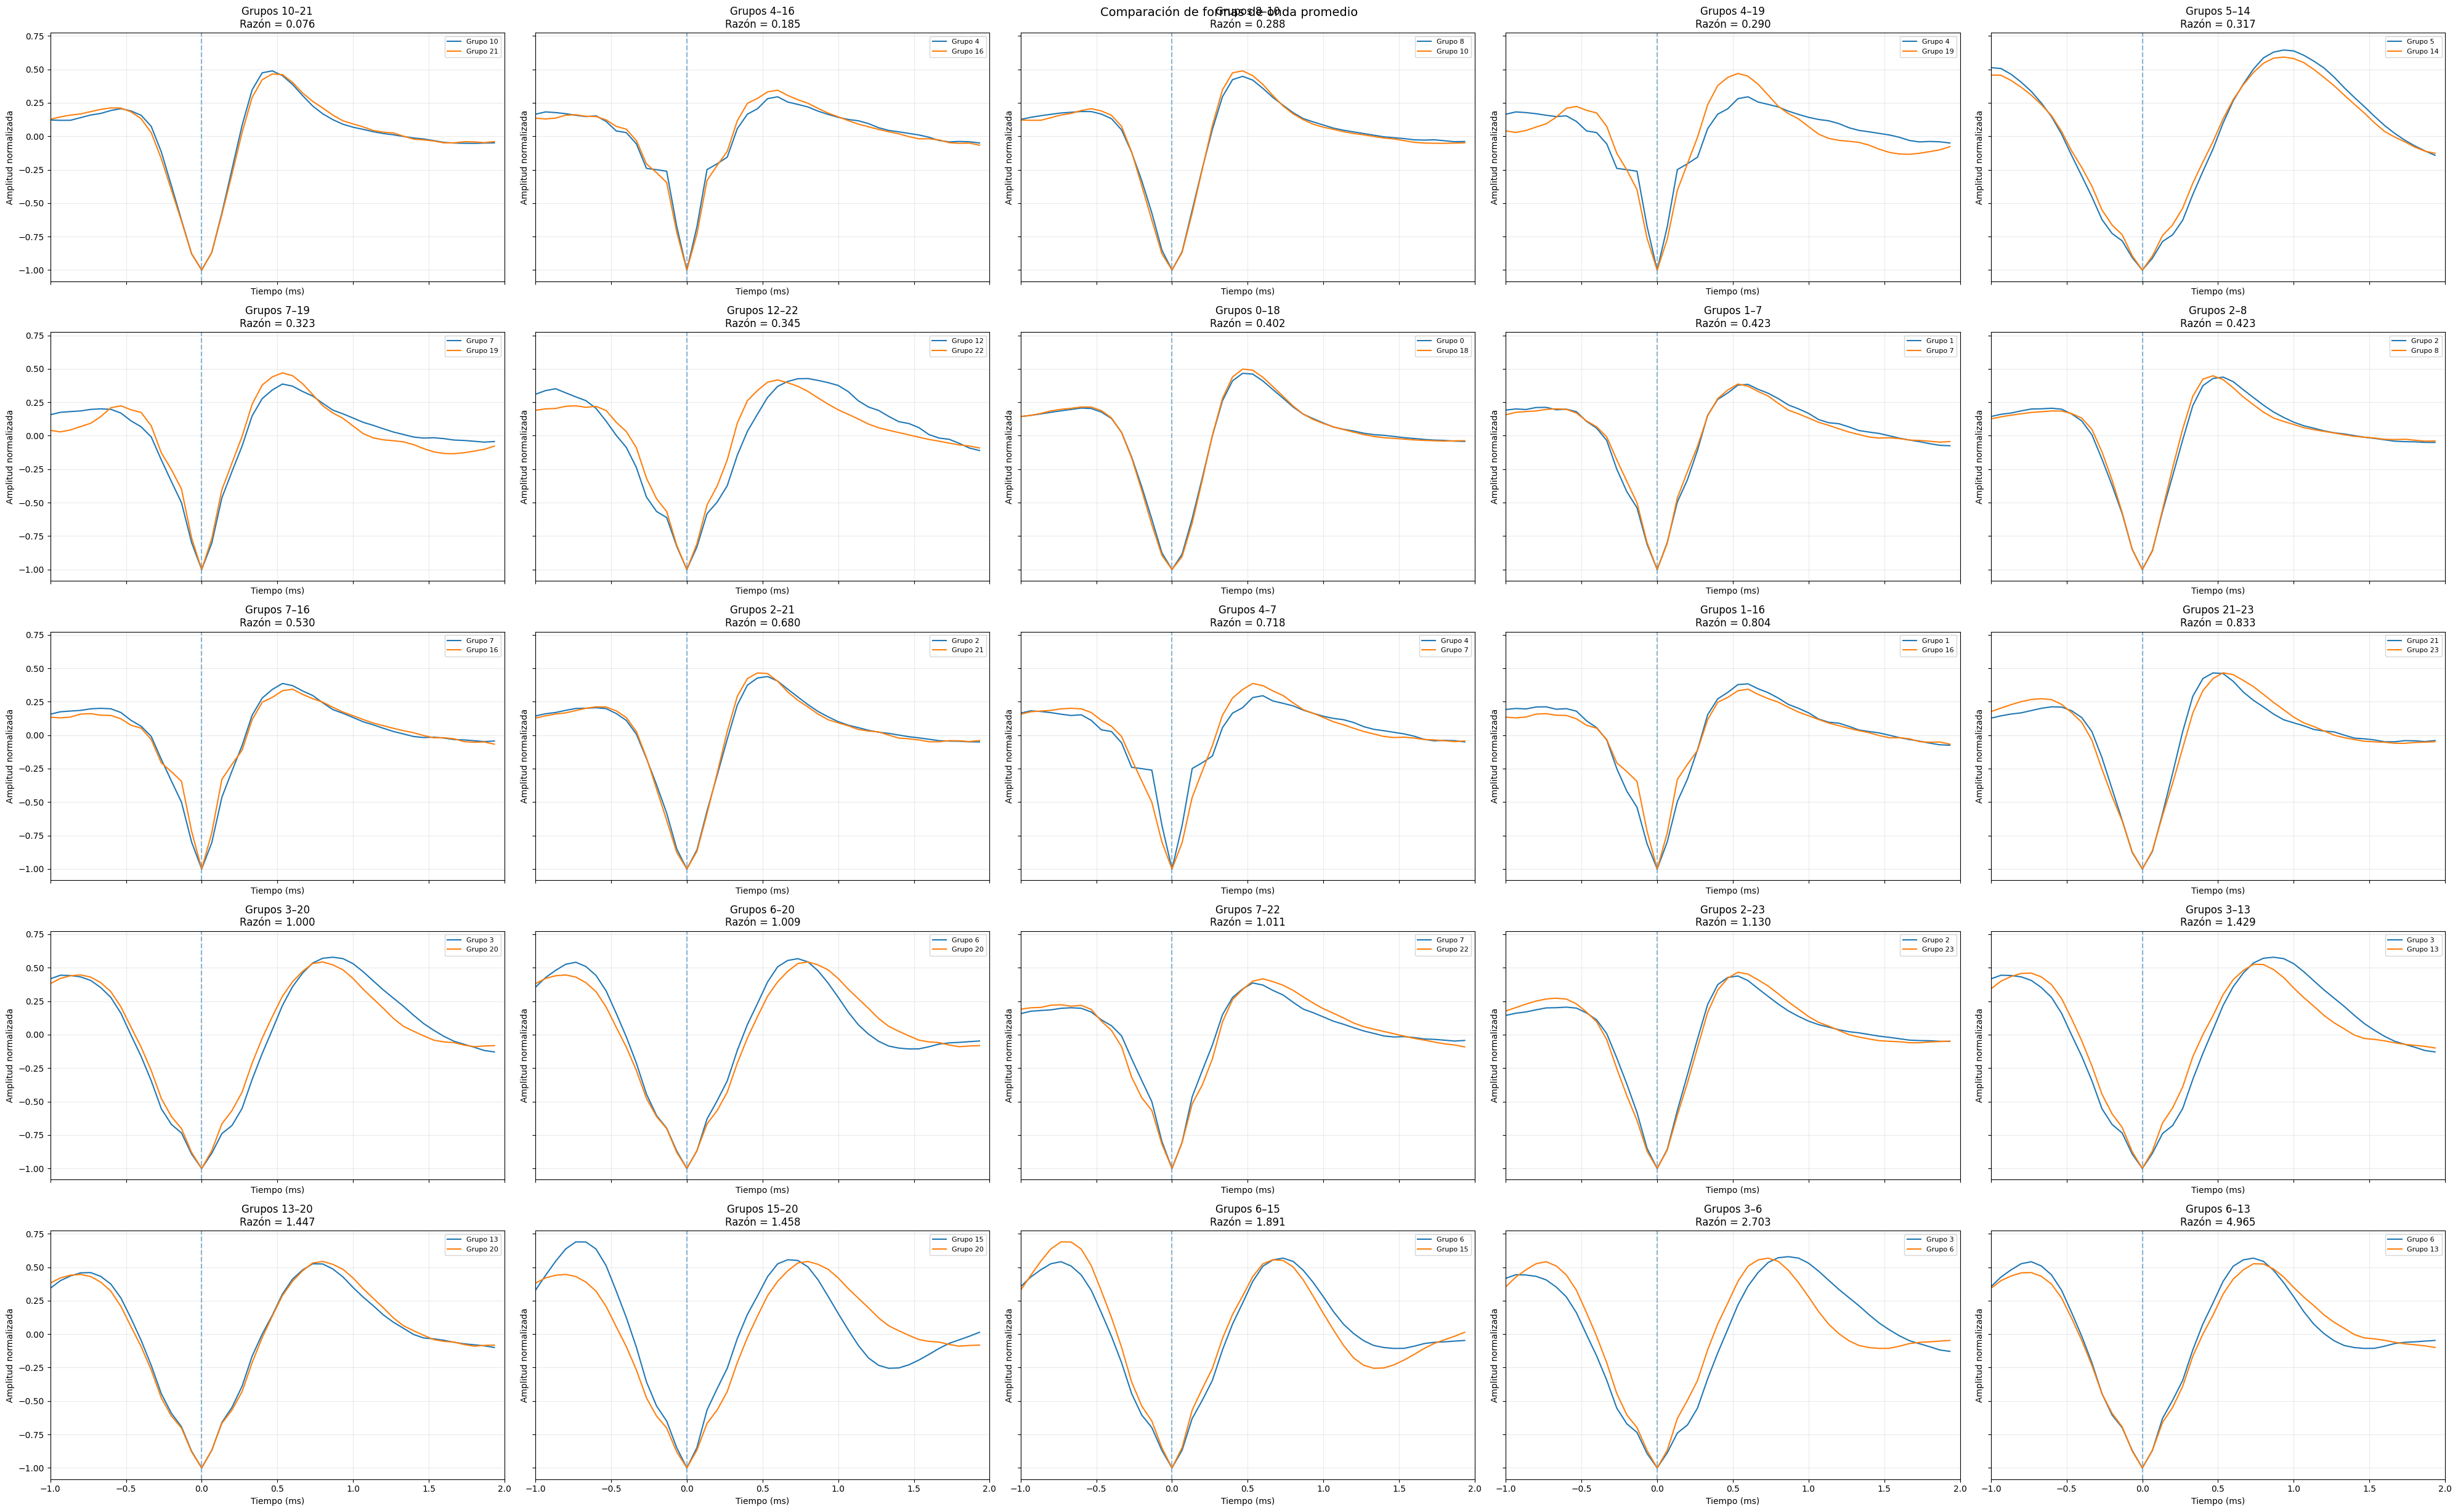

In [ ]:
# ✏️ Ejercicio 6

# ============================================================
# EJERCICIO 6 · AUTOCORRELOGRAMAS Y CORRELOGRAMAS CRUZADOS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# A. FUNCIÓN GENERAL PARA HACER CORRELOGRAMAS
# ============================================================

def correlograma(tiempos_A, tiempos_B=None,
                 max_ms=20, bin_ms=0.25):

    tiempos_A = np.sort(np.asarray(tiempos_A))

    # Si no damos B, hacemos autocorrelograma
    autocorr = tiempos_B is None

    if autocorr:
        tiempos_B = tiempos_A
    else:
        tiempos_B = np.sort(np.asarray(tiempos_B))

    max_s = max_ms / 1000
    bin_s = bin_ms / 1000

    # Bordes de -20 a +20 ms
    bordes = np.arange(
        -max_s,
        max_s + bin_s,
        bin_s
    )

    conteos = np.zeros(
        len(bordes) - 1,
        dtype=int
    )

    # Para cada disparo de A, buscar solamente los
    # disparos de B que están dentro de ±20 ms
    for t in tiempos_A:

        inicio = np.searchsorted(
            tiempos_B,
            t - max_s,
            side="left"
        )

        fin = np.searchsorted(
            tiempos_B,
            t + max_s,
            side="right"
        )

        diferencias = tiempos_B[inicio:fin] - t

        # En el autocorrelograma quitamos el disparo
        # comparado consigo mismo (Δt = 0)
        if autocorr:
            diferencias = diferencias[
                diferencias != 0
            ]

        hist, _ = np.histogram(
            diferencias,
            bins=bordes
        )

        conteos += hist

    # Centros de las barras en ms
    centros_ms = (
        (bordes[:-1] + bordes[1:])
        / 2
        * 1000
    )

    return centros_ms, conteos


# ============================================================
# FUNCIÓN PARA MEDIR QUÉ TAN VACÍA ESTÁ LA BANDA REFRACTARIA
# ============================================================

def razon_banda(centros_ms, conteos):

    distancia = np.abs(centros_ms)

    # Banda refractaria útil:
    # 0.5 a 2 ms
    mascara_centro = (
        (distancia >= 0.5) &
        (distancia <= 2)
    )

    # Actividad de referencia:
    # 5 a 20 ms
    mascara_fondo = (
        (distancia >= 5) &
        (distancia <= 20)
    )

    promedio_centro = np.mean(
        conteos[mascara_centro]
    )

    promedio_fondo = np.mean(
        conteos[mascara_fondo]
    )

    if promedio_fondo == 0:
        return np.nan

    return promedio_centro / promedio_fondo


# ============================================================
# B. AUTOCORRELOGRAMA DE TODOS LOS GRUPOS
# ============================================================

grupos_unicos = np.unique(grupos)

fig, axes = plt.subplots(
    6, 4,
    figsize=(20, 12),
    sharex=True
)

axes = axes.flatten()

razones_auto = {}

for ax, grupo in zip(axes, grupos_unicos):

    t_grupo = tiempos_v[
        grupos == grupo
    ]

    centros, conteos = correlograma(
        t_grupo,
        max_ms=20,
        bin_ms=0.25
    )

    razon = razon_banda(
        centros,
        conteos
    )

    razones_auto[grupo] = razon

    ax.bar(
        centros,
        conteos,
        width=0.25
    )

    # Líneas del período refractario
    ax.axvline(-2, linestyle="--", alpha=0.5)
    ax.axvline(2, linestyle="--", alpha=0.5)

    ax.axvline(-0.5, linestyle=":", alpha=0.5)
    ax.axvline(0.5, linestyle=":", alpha=0.5)

    ax.set_title(
        f"Grupo {grupo}\nrazón = {razon:.2f}"
    )

    ax.set_xlim(-20, 20)


for ax in axes:
    ax.set_xlabel("Δt (ms)")
    ax.set_ylabel("Conteos")

plt.tight_layout()
plt.show()

# ============================================================
# C. BUSCAR GRUPOS CERCANOS EN LA NUBE DE CARACTERÍSTICAS
# ============================================================

# Centro de cada grupo en el espacio estandarizado:
# amplitud, anchura y centroide
centros_grupos = {}

for grupo in grupos_unicos:

    centros_grupos[grupo] = np.mean(
        X_std[grupos == grupo],
        axis=0
    )


# Calcular distancia entre todos los pares
parejas = []

for i in range(len(grupos_unicos)):

    for j in range(i + 1, len(grupos_unicos)):

        g1 = grupos_unicos[i]
        g2 = grupos_unicos[j]

        distancia = np.linalg.norm(
            centros_grupos[g1]
            - centros_grupos[g2]
        )

        parejas.append(
            (g1, g2, distancia)
        )


# Ordenar de la pareja más cercana a la más lejana
parejas = sorted(
    parejas,
    key=lambda x: x[2]
)

print("10 parejas más cercanas:")
for g1, g2, distancia in parejas[:10]:
    print(
        f"Grupos {g1} y {g2} "
        f"-> distancia = {distancia:.3f}"
    )

# ============================================================
# CORRELOGRAMAS CRUZADOS DE LAS PAREJAS CERCANAS
# ============================================================

resultados_cruzados = []

for g1, g2, distancia in parejas[:25]:

    t1 = tiempos_v[
        grupos == g1
    ]

    t2 = tiempos_v[
        grupos == g2
    ]

    centros, conteos = correlograma(
        t1,
        t2,
        max_ms=20,
        bin_ms=0.25
    )

    razon = razon_banda(
        centros,
        conteos
    )

    resultados_cruzados.append(
        (g1, g2, distancia, razon)
    )


# Ordenar por razón: las más cercanas a cero primero
resultados_cruzados = sorted(
    resultados_cruzados,
    key=lambda x: (
        np.inf if np.isnan(x[3]) else x[3]
    )
)


print("\nParejas candidatas a ser la misma neurona:\n")

for g1, g2, distancia, razon in resultados_cruzados:

    print(
        f"Grupos {g1} y {g2} | "
        f"distancia = {distancia:.3f} | "
        f"razón = {razon:.3f}"
    )

# ============================================================
# GRAFICAR LAS MEJORES PAREJAS
# ============================================================

fig, axes = plt.subplots(
    6, 3,
    figsize=(36, 16)
)

axes = axes.flatten()

for ax, resultado in zip(
    axes,
    resultados_cruzados[:18]
):

    g1, g2, distancia, razon = resultado

    t1 = tiempos_v[
        grupos == g1
    ]

    t2 = tiempos_v[
        grupos == g2
    ]

    centros, conteos = correlograma(
        t1,
        t2,
        max_ms=20,
        bin_ms=0.25
    )

    ax.bar(
        centros,
        conteos,
        width=0.25
    )

    ax.axvspan(
        -2, -0.5,
        alpha=0.15
    )

    ax.axvspan(
        0.5, 2,
        alpha=0.15
    )

    ax.set_xlim(-20, 20)

    ax.set_title(
        f"Grupos {g1}–{g2}\n"
        f"razón = {razon:.3f}"
    )

    ax.set_xlabel("Δt (ms)")
    ax.set_ylabel("Conteos")

plt.tight_layout()
plt.show()

# ============================================================
# COMPARAR FORMAS DE ONDA DE TODAS LAS PAREJAS
# ============================================================

def forma_promedio_grupo(grupo):

    idx = np.where(
        grupos == grupo
    )[0]

    # Onda de cada evento tomada en SU canal pico
    ondas = np.array([
        formas_v[i, canales_metricas[i], :]
        for i in idx
    ])

    promedio = np.mean(
        ondas,
        axis=0
    )

    # Normalizar para comparar la FORMA
    # y no la amplitud absoluta
    promedio_norm = (
        promedio
        / abs(np.min(promedio))
    )

    return promedio_norm


# Tiempo de la forma de onda en ms
t_onda = (
    np.arange(formas_v.shape[2])
    / fs
    * 1000
    - 1
)


# ============================================================
# Panel de 2 filas × 5 columnas
# ============================================================

fig, axes = plt.subplots(
    5,
    5,
    figsize=(40, 25),
    sharex=True,
    sharey=True,
    layout = "constrained"
)

axes = axes.flatten()


for ax, resultado in zip(
    axes,
    resultados_cruzados
):

    g1, g2, distancia, razon = resultado

    onda1 = forma_promedio_grupo(g1)
    onda2 = forma_promedio_grupo(g2)

    # Waveforms promedio de los dos grupos
    ax.plot(
        t_onda,
        onda1,
        label=f"Grupo {g1}"
    )

    ax.plot(
        t_onda,
        onda2,
        label=f"Grupo {g2}"
    )

    # Instante del evento
    ax.axvline(
        0,
        linestyle="--",
        alpha=0.5
    )

    ax.set_xlim(-1, 2)

    ax.set_title(
        f"Grupos {g1}–{g2}\n"
        f"Razón = {razon:.3f}"
    )

    ax.set_xlabel(
        "Tiempo (ms)"
    )

    ax.set_ylabel(
        "Amplitud normalizada"
    )

    ax.legend(
        fontsize=8
    )


fig.suptitle(
    "Comparación de formas de onda promedio",
    fontsize=14
)

plt.tight_layout()
plt.show()

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos

Respuesta: B

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:* Los grupos 0 y 18 muestran un correlograma cruzado casi vacío en la ventana -2.5 ms a 2.5 ms. Ambos muestran un autocorrelograma consistente con el de una neurona individual. Al evaluar su forma de onda promedio, se observa que son muy similares. Este no sería el caso para ondas vecinas que dispararan al mismo tiempo (y por ende mostraran un correlograma cruzado vacío), Los resultados son un fuerte indicio de que no solo se trata de grupos similares, sino que ambos pueden representar la misma neurona, por lo que se decide fusionarlos


---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

Grupos antes de fusionar:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Grupos después de fusionar:
[ 0  1  2  3  4  5  6  9 11 12 13 14 15 16 17 19 20 22]

Número de grupos antes: 24
Número de grupos después: 18

TABLA FINAL:


,grupo,picos,valles,duracion_us,pendiente,razon_pico_valle,refractario_%,faltantes_%,n_disparos,etiqueta
0,0,1,1,466.7,-0.00839,0.483,0.62,0.00,1455,good
1,1,1,1,533.3,-0.00453,0.382,1.11,26.24,1980,mua
2,2,1,1,466.7,-0.00741,0.450,2.91,0.00,4191,mua
3,3,1,1,866.7,-0.00664,0.578,4.48,0.00,783,mua
4,4,1,1,600.0,-0.00435,0.295,0.52,42.47,1159,mua
5,5,1,1,933.3,-0.00683,0.645,0.40,0.00,1006,good
6,6,2,1,733.3,-0.00711,0.568,17.16,0.00,1038,noise
7,9,1,1,933.3,-0.00758,0.627,0.42,0.00,721,good
8,11,3,2,200.0,-0.00277,1.049,2.33,0.00,473,noise
9,12,1,1,800.0,-0.00408,0.427,0.94,32.19,321,mua



Diccionario de etiquetas:
{0: 'good', 1: 'mua', 2: 'mua', 3: 'mua', 4: 'mua', 5: 'good', 6: 'noise', 9: 'good', 11: 'noise', 12: 'mua', 13: 'mua', 14: 'mua', 15: 'noise', 16: 'mua', 17: 'good', 19: 'noise', 20: 'mua', 22: 'noise'}

Cantidad de grupos por etiqueta:
etiqueta
mua      9
noise    5
good     4
Name: count, dtype: int64

Grupos que pasan a la figura resumen:
[np.int32(0), np.int32(5), np.int32(9), np.int32(17)]


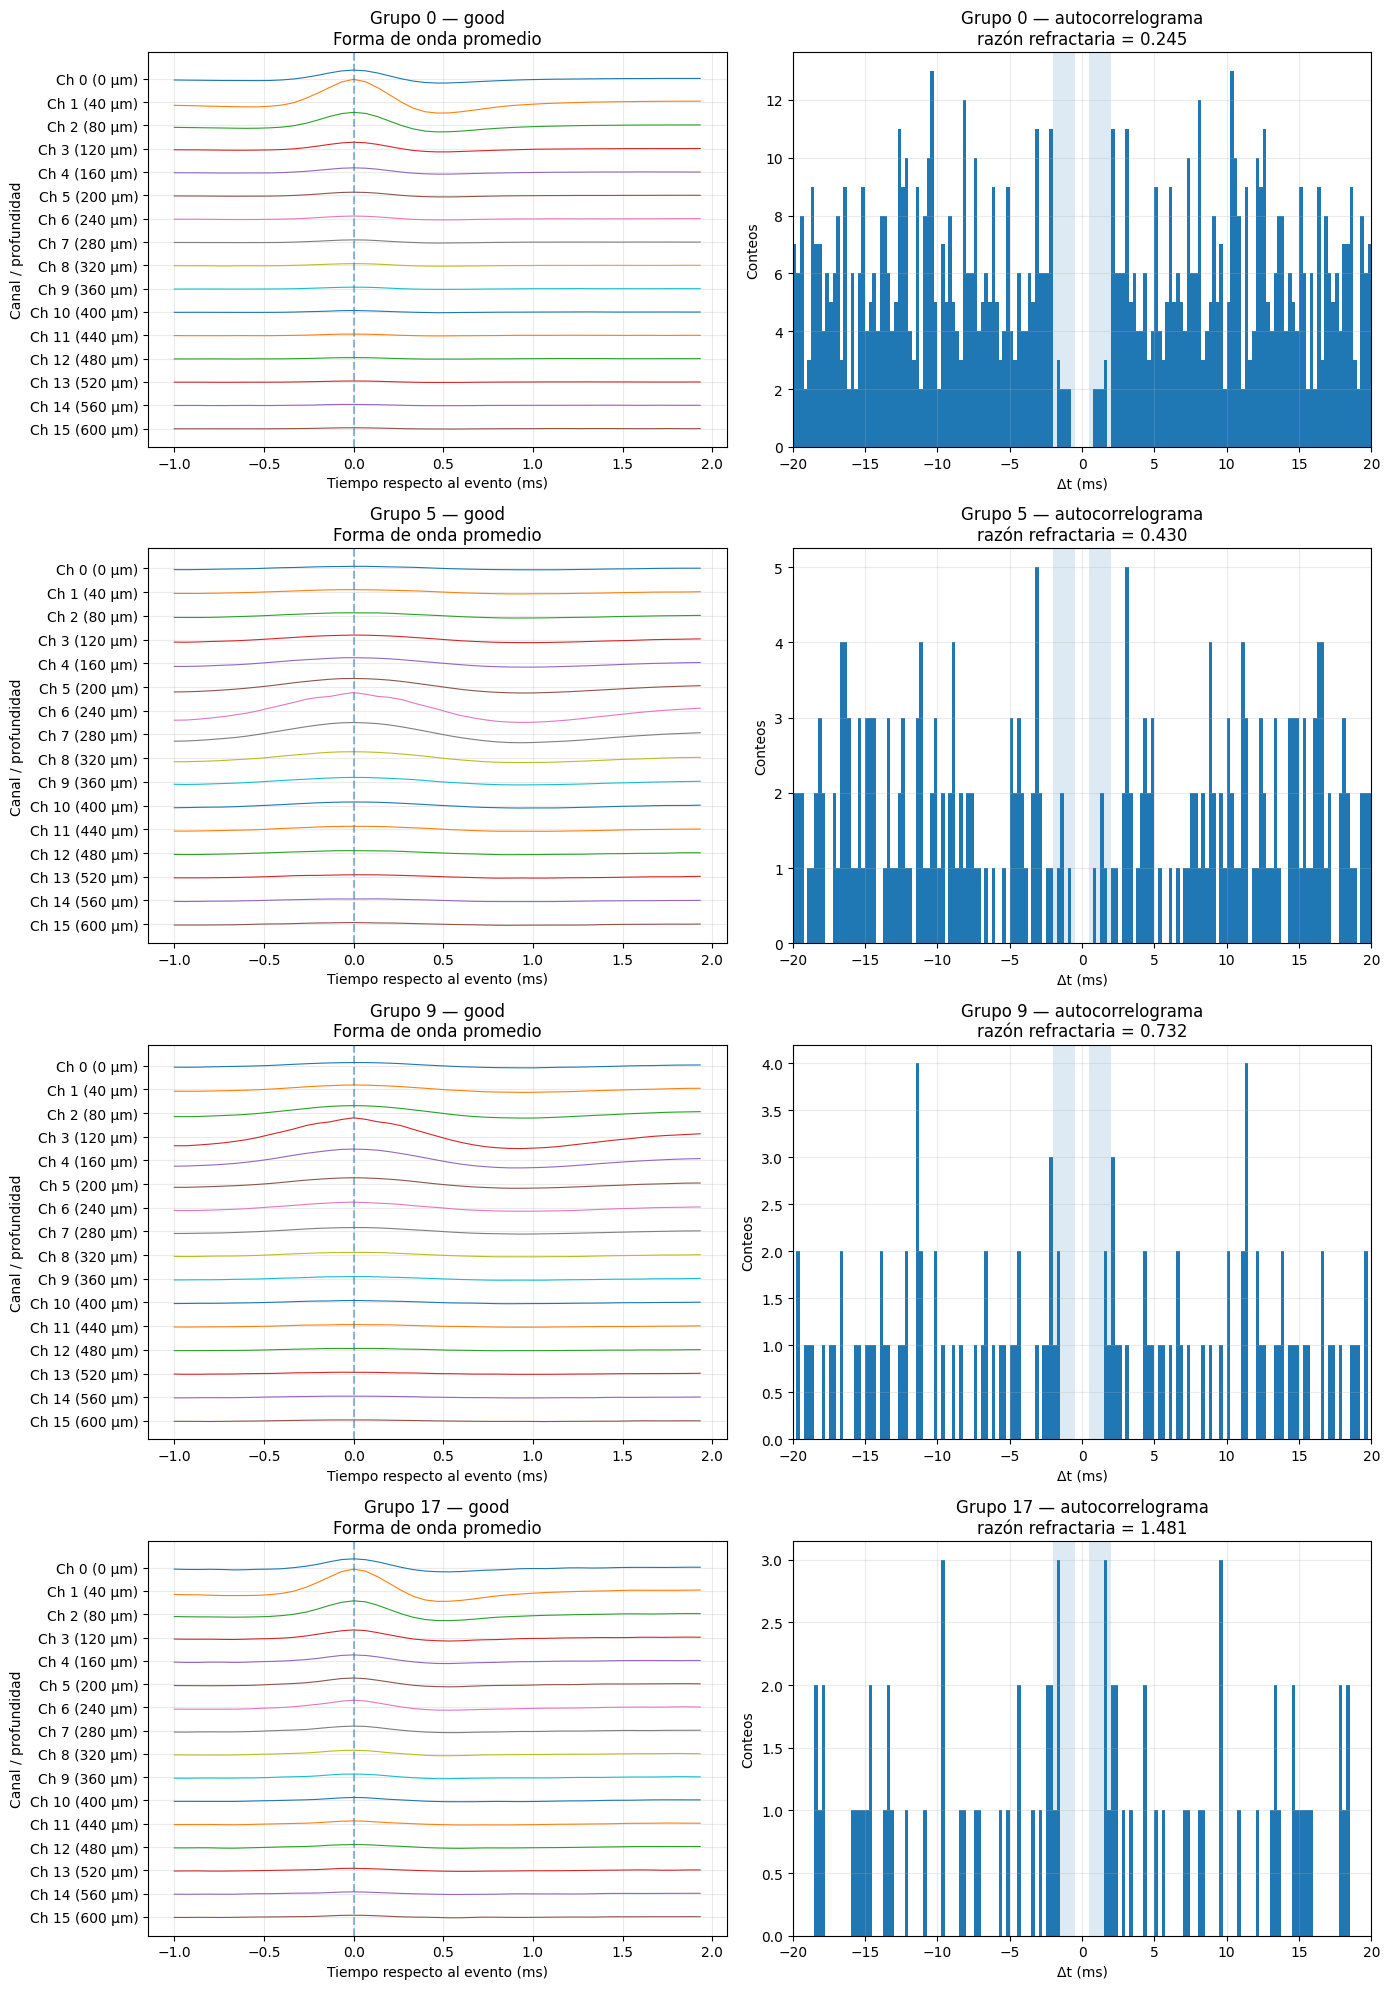

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# A. APLICAR LAS FUSIONES DECIDIDAS EN EL PUNTO 6
# ============================================================

# Copiamos los grupos originales de K-means
# ============================================================
# A. APLICAR LA FUSIÓN DECIDIDA EN EL PUNTO 6
# ============================================================

# Copiamos los grupos originales de K-means
grupos_curados = grupos.copy()
grupos_curados[grupos_curados == 18] = 0
grupos_curados[grupos_curados == 7] = 1
grupos_a_fusionar_a = [2, 8, 10, 21,23]
grupo_destino_a = 2

grupos_curados[
     np.isin(grupos_curados, grupos_a_fusionar_a)
] = grupo_destino_a

# Fusionamos grupos

# grupos_curados[grupos_curados == 6] = 1

# grupos_a_fusionar_a = [0,3,5,13]
# grupo_destino_a = 3

# grupos_curados[
#     np.isin(grupos_curados, grupos_a_fusionar_a)
# ] = grupo_destino_a


print("Grupos antes de fusionar:")
print(np.unique(grupos))

print("\nGrupos después de fusionar:")
print(np.unique(grupos_curados))

print("\nNúmero de grupos antes:", len(np.unique(grupos)))
print("Número de grupos después:", len(np.unique(grupos_curados)))


# ============================================================
# RECALCULAR LAS MÉTRICAS DESPUÉS DE LA FUSIÓN
# ============================================================

tabla_curada = calcular_metricas_grupos(
    formas=formas_v,
    tiempos=tiempos_v,
    canales_metricas=canales_metricas,
    amplitudes=amplitud, # Corregido: 'amplitud_v' -> 'amplitud'
    grupos=grupos_curados,
    profundidad=profundidad,
    filtrada=filtrada,
    fs=fs,
    k_umbral=4.5
)

tabla_curada = (
    tabla_curada
    .sort_values("grupo")
    .reset_index(drop=True)
)


# ============================================================
# B. ASIGNAR UNA ETIQUETA A CADA GRUPO
# ============================================================

def etiquetar_grupo(fila):

    # --------------------------------------------------------
    # 1. NOISE
    # --------------------------------------------------------
    # No parece actividad neuronal:
    # - demasiados picos o valles
    # - duración fuera de rango
    # - caída espacial demasiado plana

    es_noise = (
        fila["picos"] >= 2
        or fila["valles"] >= 2
        or np.isnan(fila["duracion_us"])
        or fila["duracion_us"] < 100
        or fila["duracion_us"] > 1150
        or np.isnan(fila["pendiente"])
        or fila["pendiente"] >= -0.004
    )

    if es_noise:
        return "noise"

    # --------------------------------------------------------
    # 3. NON-SOMATIC
    # --------------------------------------------------------
    # Pasa los criterios anteriores, pero el pico positivo
    # es muy grande respecto al valle.

    if fila["razon_pico_valle"] > 0.8:
        return "nonsomatic"

    # --------------------------------------------------------
    # 2. MUA
    # --------------------------------------------------------
    # Hay actividad neuronal, pero no corresponde
    # a una unidad bien aislada o completa.

    es_mua = (
        np.isnan(fila["refractario_%"])
        or fila["refractario_%"] >= 1.5
        or np.isnan(fila["faltantes_%"])
        or fila["faltantes_%"] >= 20
        or fila["n_disparos"] < 300
    )

    if es_mua:
        return "mua"





    # --------------------------------------------------------
    # 4. GOOD
    # --------------------------------------------------------
    # Si pasa todos los criterios anteriores,
    # queda como unidad bien aislada.

    return "good"


# ============================================================
# APLICAR LA FUNCIÓN A TODOS LOS GRUPOS
# ============================================================

tabla_curada["etiqueta"] = tabla_curada.apply(
    etiquetar_grupo,
    axis=1
)


# ============================================================
# CREAR EL DICCIONARIO DE ETIQUETAS
# ============================================================

etiquetas = dict(
    zip(
        tabla_curada["grupo"].astype(int),
        tabla_curada["etiqueta"]
    )
)


# ============================================================
# MOSTRAR LA TABLA FINAL
# ============================================================

tabla_final = tabla_curada[
    [
        "grupo",
        "picos",
        "valles",
        "duracion_us",
        "pendiente",
        "razon_pico_valle",
        "refractario_%",
        "faltantes_%",
        "n_disparos",
        "etiqueta"
    ]
].copy()


tabla_final = tabla_final.round({
    "duracion_us": 1,
    "pendiente": 5,
    "razon_pico_valle": 3,
    "refractario_%": 2,
    "faltantes_%": 2
})


print("\nTABLA FINAL:")
display(tabla_final)


print("\nDiccionario de etiquetas:")
print(etiquetas)


print("\nCantidad de grupos por etiqueta:")
print(
    tabla_curada["etiqueta"].value_counts()
)


# ============================================================
# C. FIGURA RESUMEN
# SOLO GOOD Y NONSOMATIC
# ============================================================

grupos_mostrar = [
    g for g in np.unique(grupos_curados)
    if etiquetas[int(g)] in ["good", "nonsomatic"]
]


print("\nGrupos que pasan a la figura resumen:")
print(grupos_mostrar)


if len(grupos_mostrar) == 0:

    print("No hay grupos etiquetados como good o nonsomatic.")

elif len(grupos_mostrar) == 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), squeeze=False)
    axes_flat = axes.flatten()
    for fila, grupo in enumerate(grupos_mostrar):
        idx = np.where(grupos_curados == grupo)[0]
        forma_promedio = np.mean(formas_v[idx], axis=0)
        t_ms = (np.arange(forma_promedio.shape[1]) / fs * 1000 - 1)

        ax1 = axes_flat[0]
        offset = (2.0 * np.percentile(np.abs(forma_promedio), 99))
        if offset == 0: offset = 1
        for canal in range(16):
            ax1.plot(t_ms, forma_promedio[canal] + canal * offset, linewidth=0.8)
        ax1.set_yticks(np.arange(16) * offset)
        ax1.set_yticklabels([f"Ch {canal} ({profundidad[canal]:.0f} µm)" for canal in range(16)])
        ax1.invert_yaxis()
        ax1.axvline(0, linestyle="--", alpha=0.5)
        ax1.set_xlabel("Tiempo respecto al evento (ms)")
        ax1.set_ylabel("Canal / profundidad")
        ax1.set_title(f"Grupo {grupo} — {etiquetas[int(grupo)]}\nForma de onda promedio")

        tiempos_grupo = tiempos_v[grupos_curados == grupo]
        centros, conteos = correlograma(tiempos_grupo, max_ms=20, bin_ms=0.25)
        razon = razon_banda(centros, conteos)

        ax2 = axes_flat[1]
        ax2.bar(centros, conteos, width=0.25)
        ax2.axvspan(-2, -0.5, alpha=0.15)
        ax2.axvspan(0.5, 2, alpha=0.15)
        ax2.set_xlim(-20, 20)
        ax2.set_xlabel("Δt (ms)")
        ax2.set_ylabel("Conteos")
        ax2.set_title(f"Grupo {grupo} — autocorrelograma\nrazón refractaria = {razon:.3f}")

    plt.tight_layout()
    plt.show()

else:

    fig, axes = plt.subplots(
        len(grupos_mostrar),
        2,
        figsize=(14, 5 * len(grupos_mostrar)),
        squeeze=False
    )


    for fila, grupo in enumerate(grupos_mostrar):

        # Eventos pertenecientes a este grupo
        idx = np.where(
            grupos_curados == grupo
        )[0]


        # ====================================================
        # IZQUIERDA: FORMA PROMEDIO EN LOS 16 SITIOS
        # ====================================================

        forma_promedio = np.mean(
            formas_v[idx],
            axis=0
        )

        # Tiempo de -1 a +2 ms
        t_ms = (
            np.arange(forma_promedio.shape[1])
            / fs
            * 1000
            - 1
        )


        ax1 = axes[fila, 0]


        # Separación vertical para poder ver los 16 canales
        offset = (
            2.0
            * np.percentile(
                np.abs(forma_promedio),
                99
            )
        )

        if offset == 0:
            offset = 1


        for canal in range(16):

            ax1.plot(
                t_ms,
                forma_promedio[canal]
                + canal * offset,
                linewidth=0.8
            )


        ax1.set_yticks(
            np.arange(16) * offset
        )

        ax1.set_yticklabels([
            f"Ch {canal} ({profundidad[canal]:.0f} µm)"
            for canal in range(16)
        ])

        ax1.invert_yaxis()

        ax1.axvline(
            0,
            linestyle="--",
            alpha=0.5
        )

        ax1.set_xlabel(
            "Tiempo respecto al evento (ms)"
        )

        ax1.set_ylabel(
            "Canal / profundidad"
        )

        ax1.set_title(
            f"Grupo {grupo} — {etiquetas[int(grupo)]}\n"
            "Forma de onda promedio"
        )


        # ====================================================
        # DERECHA: AUTOCORRELOGRAMA
        # ====================================================

        tiempos_grupo = tiempos_v[
            grupos_curados == grupo
        ]


        centros, conteos = correlograma(
            tiempos_grupo,
            max_ms=20,
            bin_ms=0.25
        )


        razon = razon_banda(
            centros,
            conteos
        )


        ax2 = axes[fila, 1]

        ax2.bar(
            centros,
            conteos,
            width=0.25
        )


        # Banda refractaria que sí debemos evaluar
        ax2.axvspan(
            -2,
            -0.5,
            alpha=0.15
        )

        ax2.axvspan(
            0.5,
            2,
            alpha=0.15
        )


        ax2.set_xlim(
            -20,
            20
        )

        ax2.set_xlabel(
            "Δt (ms)"
        )

        ax2.set_ylabel(
            "Conteos"
        )

        ax2.set_title(
            f"Grupo {grupo} — autocorrelograma\n"
            f"razón refractaria = {razon:.3f}"
        )


    plt.tight_layout()
    plt.show()

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`

Respuesta: D

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.

*Su respuesta:*

El grupo 11 es etiquetado como noise, y las características que lo deciden son la detección de hasta 3 picos y 2 valles por evento, además de tener una caída de -0.00277 > -0.004 y un porcentaje de eventos por debajo del refractario de 2.33% > 1.5%.

El grupo 1 es etiquetado como mua, y la característica que lo decide es un porcentaje de disparos faltantes de 26.24% > 20%.

El grupo 0 es etiquetado como good porque: no se detectan más de 2 picos ni valles por evento, la duración de evento entra dentro de la ventana de 100-1150 microsegundos, la caída es de -0.00839 < -0.004, su razón pico/valle es de 0.483 < 0.8, su porcentaje de disparos faltantes es del 0%, su porcentaje de eventos por debajo del refractario es de 0.62% < 1.5%, y abarca 1455 > 300 potenciales de acción. El grupo 0 pasa todos los filtros y puede etiquetarse como good.


---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [ ]:
grupos_validos_verificacion = [
    grupo for grupo, etiqueta in etiquetas.items()
    if etiqueta not in ["noise", "mua"]
]

# Seleccionar únicamente los disparos de esos grupos
mascara_verificacion = np.isin(
    grupos_curados,
    grupos_validos_verificacion
)

tiempos_verificacion = tiempos_v[mascara_verificacion]

print("Grupos incluidos:", grupos_validos_verificacion)
print("Número de disparos para verificar:", len(tiempos_verificacion))

Grupos incluidos: [0, 5, 9, 17]
Número de disparos para verificar: 3591


In [ ]:
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos_v, canales_metricas)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos_v, grupos)       # matriz de confusión
v.verificar_curacion(tiempos_v, grupos_curados, etiquetas)   # ¿acertaron las etiquetas?

Verificación configurada con: taller2_ruidosa.h5
  detectados 18639
  verdaderos positivos 18427   falsos positivos 212
  precisión     0.989  ████████████████████████████
  exhaustividad 0.885  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.934  ██████████████████████████··
  faltan 1589 disparos de unidades bien aisladas

  de una unidad identificable  0.653  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.
  sobre 18345 detecciones emparejadas:
  canal exacto        0.636  ██████████████████··········
  a un sitio o menos  0.819  ███████████████████████·····
  nota: en la actividad multiunitaria el canal pico es inestable por
  naturaleza, así que no espere acertarle a todo.
  filas = sus grupos, columnas = la verdad

  grupo        U1     U2     U3     U4     U5

0.7777777777777778

In [ ]:
v.verificar_deteccion(tiempos_verificacion)

  detectados 3591
  verdaderos positivos 3591   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.250  ███████·····················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.401  ███████████·················
  faltan 10313 disparos de unidades bien aisladas

  de una unidad identificable  0.959  ███████████████████████████·
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.2503997674080535),
 'f1': np.float64(0.4005115386851131),
 'util': 0.9593428014480646}

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

Respuesta: B

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:* La fracción de una unidad identificable sube de 0.653 a 0.959 (diferencia = 0.306). Obtuvimos 4/4 unidades good posibles según verificar_curacion(). La matriz de confusión muestra 8 unidades de datos (U1-U8) La U1 está dividida entre los grupos 0, 17 y 18, de los cuales se fusionaron 0 y 18. La U2 está mayormente concentrada en el grupo 9, pero tiene 100 eventos en el grupo 14. La U3 está dividida entre los grupos 2, 8, 10 y 21, y las fusionamos en el grupo 2. La U4 quedó fragmentada, con  la mayoría de eventos en los grupos 5 y 14. La U5 quedó en divida en los grupos 2, 21 y 23, que fueron juntados en el grupo 2. Es decir, U3 y U5 están mezcladas en el grupo 2. La U6 quedó fragmentada en los grupos 3, 6, 13 y 20. La U7 quedó separada entre los grupos 1, 7 y 16, de los cuales solo 1 y 7 se fusionaron. La U8 quedó fragmentada en los grupos 6, 13 y 15. En general, los grupos creados con K-means no lograron separar limpiamente varias de las neuronas reales presentes.


---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

Datasets dentro de 'estimulos':
condicion -> (60,) |S1
tiempo_inicio_s -> (60,) float64
Dataset de inicios: tiempo_inicio_s
Dataset de etiquetas: condicion

Número de ensayos: 60

Primeros inicios:
[20. 23. 26. 29. 32. 35. 38. 41. 44. 47.]

Primeras etiquetas:
['C' 'C' 'B' 'B' 'B' 'C' 'B' 'B' 'A' 'A']
Disparos asignados a ensayos: 16956
Primeros tiempos relativos: [-0.97733333 -0.97433333 -0.95386667 -0.90573333 -0.90313333 -0.9004
 -0.88453333 -0.87986667 -0.87386667 -0.87033333]
Primeros números de ensayo: [0 0 0 0 0 0 0 0 0 0]
Primeras condiciones: ['C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C']
Grupos good / nonsomatic: [np.int32(0), np.int32(5), np.int32(9), np.int32(17)]


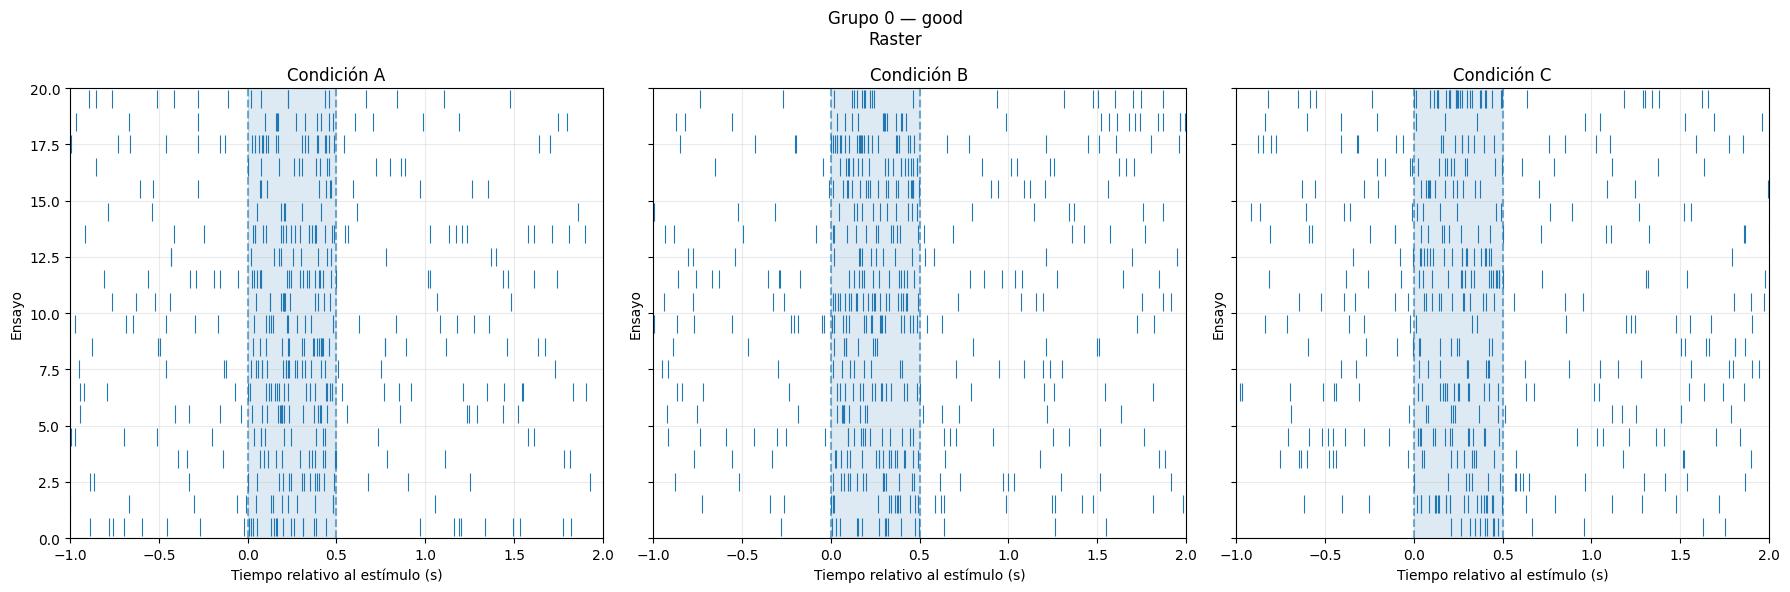

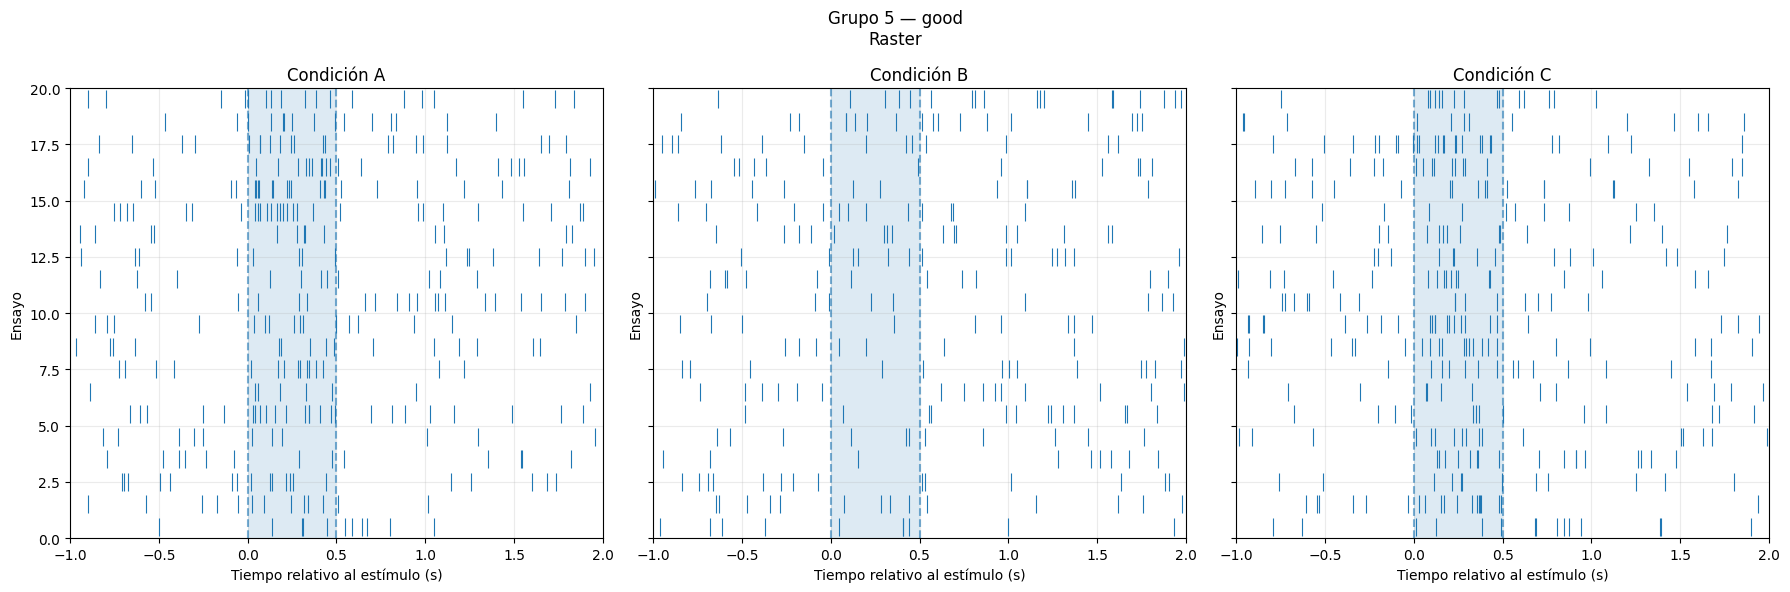

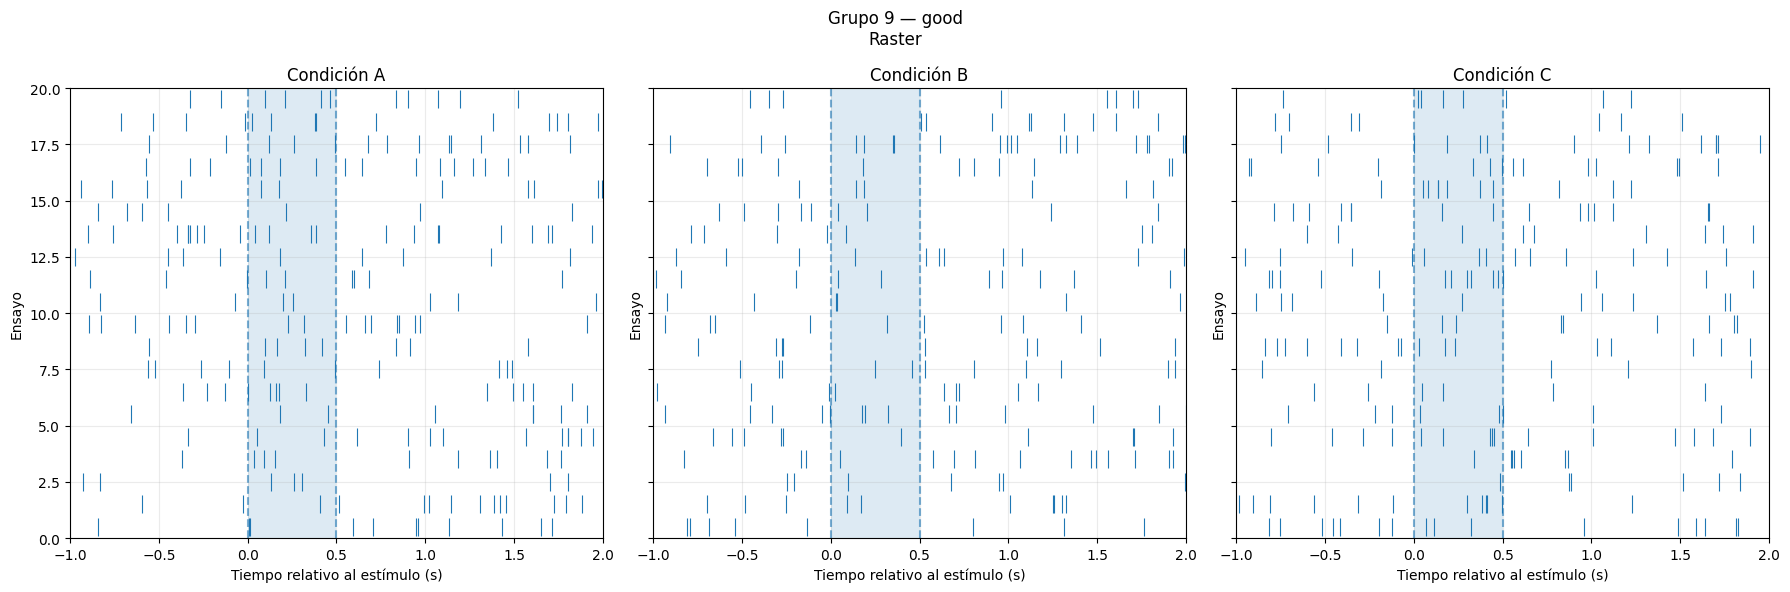

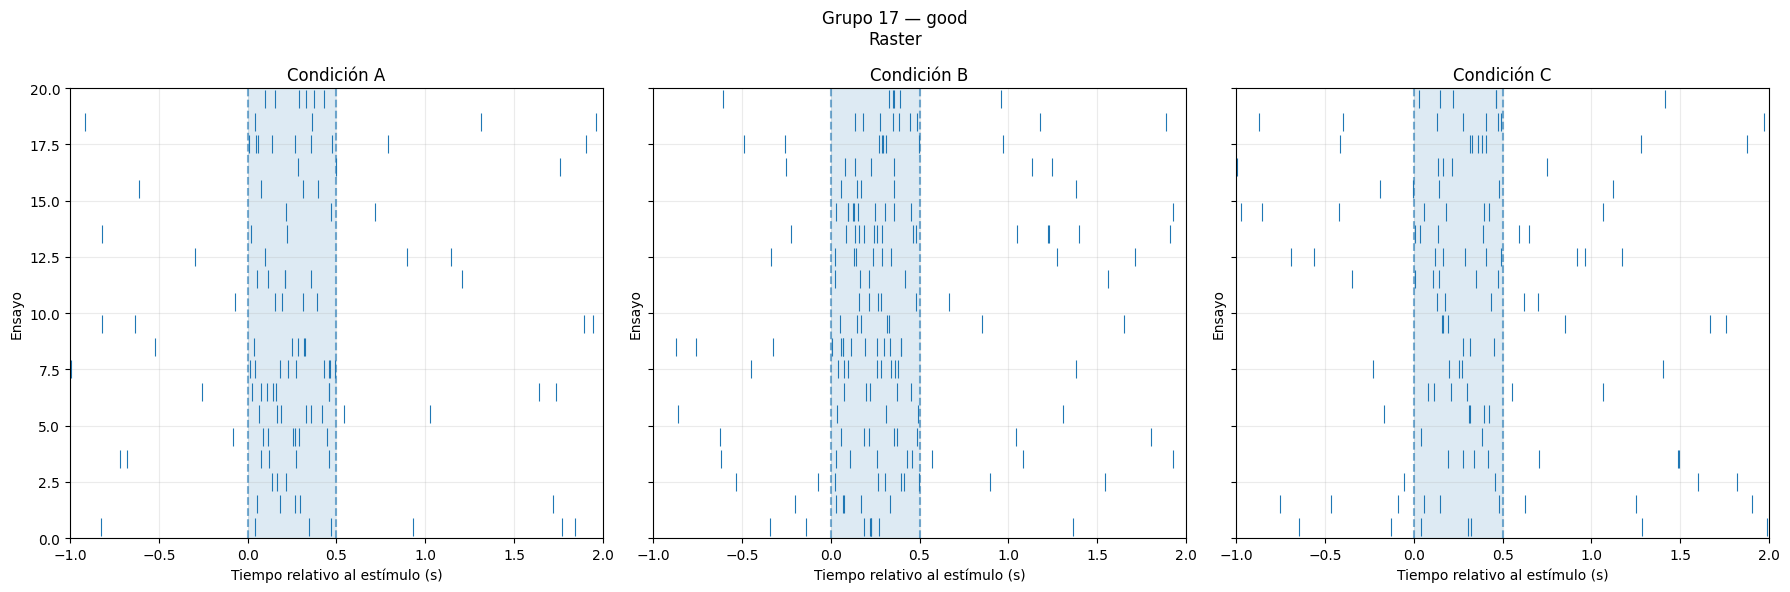

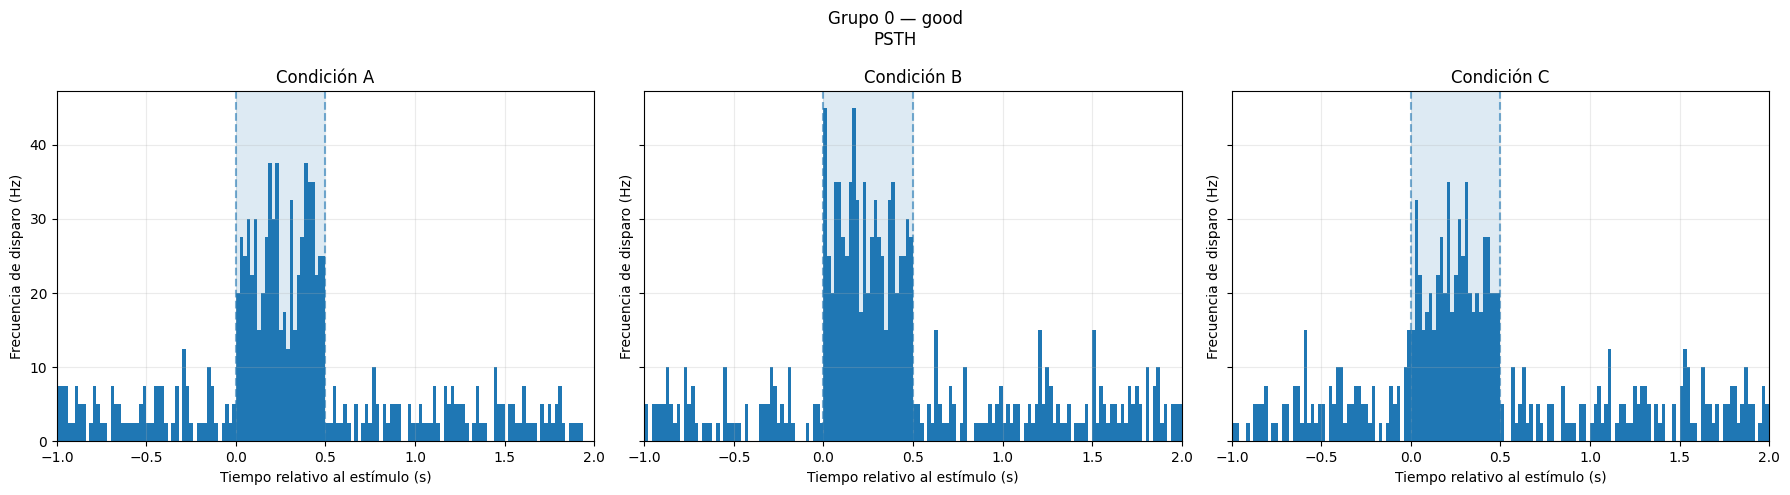

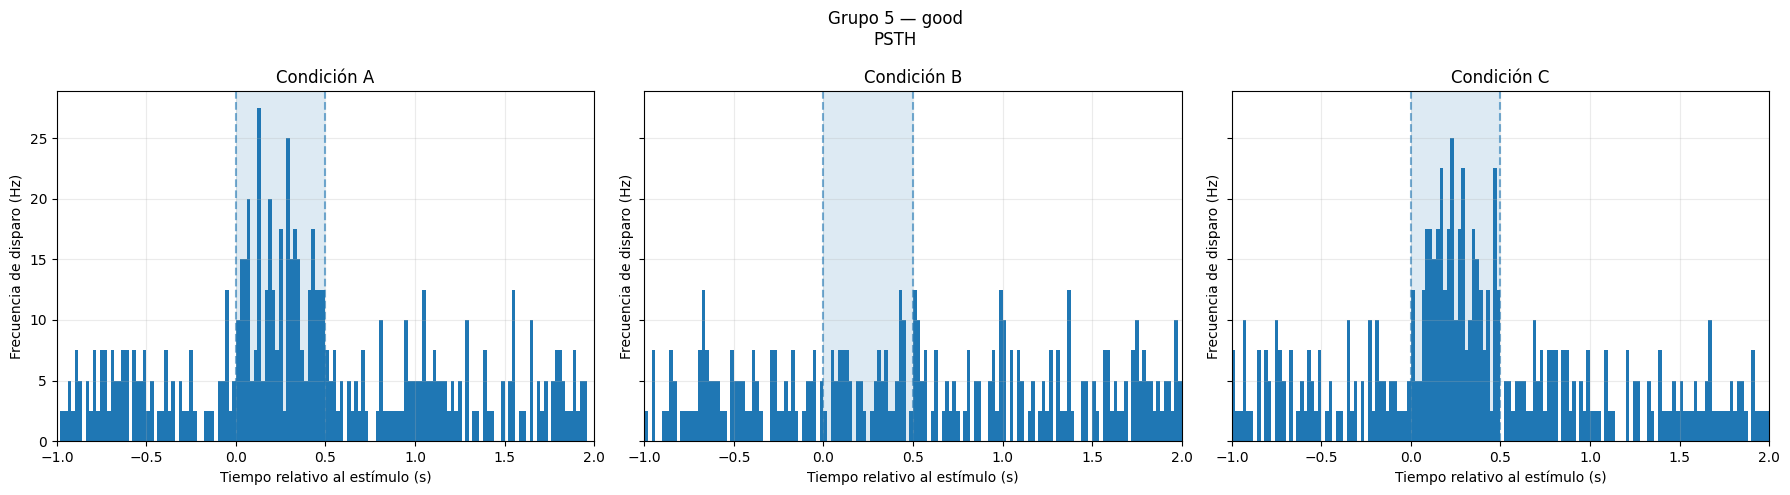

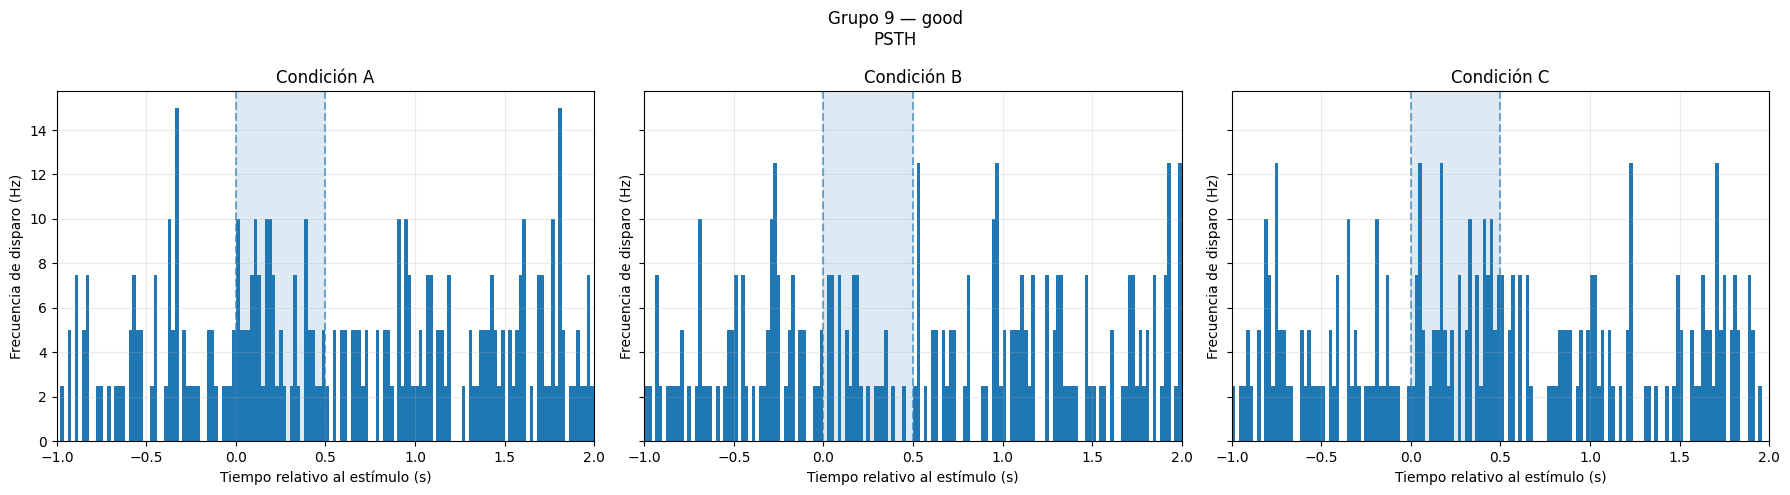

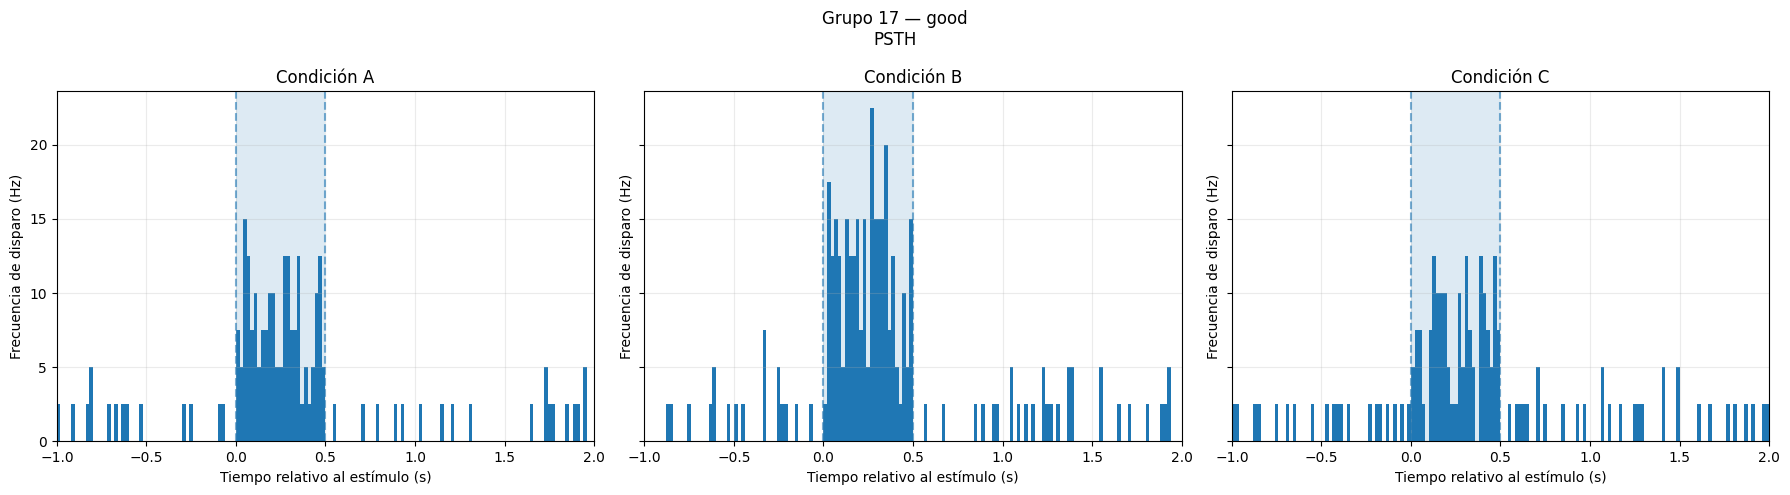

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. PARÁMETROS
# ============================================================

ARCHIVO = "taller2_ruidosa.h5"

# Ventana temporal relativa al inicio del estímulo
PRE_ESTIMULO_S = 1.0
DURACION_ESTIMULO_S = 0.5
POST_ESTIMULO_S = 1.5

T_INICIO = -PRE_ESTIMULO_S
T_FIN = DURACION_ESTIMULO_S + POST_ESTIMULO_S

# Ancho de los bins del PSTH
BIN_PSTH_MS = 20
BIN_PSTH_S = BIN_PSTH_MS / 1000

# Condiciones
CONDICIONES = ["A", "B", "C"]


# ============================================================
# 1. LEER LOS INICIOS Y LAS ETIQUETAS DE LOS ENSAYOS
# ============================================================

with h5py.File(ARCHIVO, "r") as f:

    estimulos = f["estimulos"]

    print("Datasets dentro de 'estimulos':")

    for nombre in estimulos.keys():
        print(
            nombre,
            "->",
            estimulos[nombre].shape,
            estimulos[nombre].dtype
        )
# ============================================================
# 2. ENCONTRAR AUTOMÁTICAMENTE LOS DATASETS DE ESTÍMULOS
# ============================================================

def buscar_dataset_estimulos(grupo_estimulos, palabras):

    candidatos = []

    for nombre in grupo_estimulos.keys():

        nombre_minuscula = nombre.lower()

        if any(
            palabra in nombre_minuscula
            for palabra in palabras
        ):
            candidatos.append(nombre)

    if len(candidatos) == 1:
        return candidatos[0]

    if len(candidatos) > 1:
        print(
            "Varios candidatos encontrados:",
            candidatos
        )
        return candidatos[0]

    return None


with h5py.File(ARCHIVO, "r") as f:

    estimulos = f["estimulos"]

    nombre_inicios = buscar_dataset_estimulos(
        estimulos,
        [
            "inicio",
            "start",
            "tiempo",
            "time"
        ]
    )

    nombre_etiquetas = buscar_dataset_estimulos(
        estimulos,
        [
            "etiqueta",
            "label",
            "condicion",
            "condition"
        ]
    )

    if nombre_inicios is None or nombre_etiquetas is None:

        raise ValueError(
            "No fue posible identificar automáticamente "
            "los datasets de inicio y etiqueta dentro de "
            "'estimulos'. Revisa la impresión anterior."
        )

    inicios_ensayo = np.asarray(
        estimulos[nombre_inicios][:]
    ).astype(float)

    etiquetas_ensayo = np.asarray(
        estimulos[nombre_etiquetas][:]
    )

    # Convertir bytes a strings si fuera necesario
    etiquetas_ensayo = np.array([
        x.decode() if isinstance(x, bytes) else str(x)
        for x in etiquetas_ensayo
    ])


print("Dataset de inicios:", nombre_inicios)
print("Dataset de etiquetas:", nombre_etiquetas)

print("\nNúmero de ensayos:", len(inicios_ensayo))

print("\nPrimeros inicios:")
print(inicios_ensayo[:10])

print("\nPrimeras etiquetas:")
print(etiquetas_ensayo[:10])


assert len(inicios_ensayo) == len(etiquetas_ensayo)

# ============================================================
# 3. CONVERTIR TIEMPOS ABSOLUTOS A TIEMPOS RELATIVOS
# ============================================================

def convertir_tiempos_relativos(
    tiempos_absolutos,
    grupos_absolutos,
    inicios_ensayo,
    etiquetas_ensayo,
    pre_s=1.0,
    duracion_estimulo_s=0.5,
    post_s=1.5
):

    tiempos_absolutos = np.asarray(
        tiempos_absolutos
    )

    grupos_absolutos = np.asarray(
        grupos_absolutos
    )

    inicios_ensayo = np.asarray(
        inicios_ensayo
    )

    etiquetas_ensayo = np.asarray(
        etiquetas_ensayo
    )

    tiempos_relativos = []
    numeros_ensayo = []
    condiciones = []
    grupos_eventos_en_ensayo = []

    # Ventana total que queremos conservar:
    # 1 s antes del estímulo + 0.5 s de estímulo + 1.5 s después
    ventana_inicio = -pre_s
    ventana_fin = duracion_estimulo_s + post_s

    # Recorrer todos los ensayos
    for ensayo, inicio in enumerate(
        inicios_ensayo
    ):

        # ========================================================
        # INICIO REAL DEL ESTÍMULO
        # ========================================================

        inicio_estimulo = inicio + pre_s

        # ========================================================
        # LÍMITES ABSOLUTOS DE LA VENTANA
        # ========================================================

        limite_inferior = (
            inicio_estimulo + ventana_inicio
        )

        limite_superior = (
            inicio_estimulo + ventana_fin
        )

        # ========================================================
        # DISPAROS DENTRO DE LA VENTANA
        # ========================================================

        mascara = (
            (tiempos_absolutos >= limite_inferior)
            &
            (tiempos_absolutos < limite_superior)
        )

        tiempos = tiempos_absolutos[
            mascara
        ]

        grupos_filtrados_por_ensayo = grupos_absolutos[
            mascara
        ]

        # ========================================================
        # CONVERTIR A TIEMPO RELATIVO AL INICIO DEL ESTÍMULO
        # ========================================================

        tiempos_rel = (
            tiempos - inicio_estimulo
        )

        tiempos_relativos.extend(
            tiempos_rel
        )

        grupos_eventos_en_ensayo.extend(
            grupos_filtrados_por_ensayo
        )

        numeros_ensayo.extend(
            [ensayo] * len(tiempos_rel)
        )

        condiciones.extend(
            [etiquetas_ensayo[ensayo]]
            * len(tiempos_rel)
        )

    return (
        np.asarray(tiempos_relativos),
        np.asarray(grupos_eventos_en_ensayo, dtype=int),
        np.asarray(numeros_ensayo, dtype=int),
        np.asarray(condiciones)
    )
# ============================================================
# Aplicar a TODOS los disparos válidos
# ============================================================

tiempos_relativos, grupos_eventos_en_ensayo, numeros_ensayo, condiciones = ( # <--- Update return values
    convertir_tiempos_relativos(
        tiempos_v,
        grupos_curados, # <--- Pass grupos_curados
        inicios_ensayo,
        etiquetas_ensayo,
        pre_s=PRE_ESTIMULO_S,
        duracion_estimulo_s=DURACION_ESTIMULO_S,
        post_s=POST_ESTIMULO_S
    )
)


print(
    "Disparos asignados a ensayos:",
    len(tiempos_relativos)
)

print(
    "Primeros tiempos relativos:",
    tiempos_relativos[:10]
)

print(
    "Primeros números de ensayo:",
    numeros_ensayo[:10]
)

print(
    "Primeras condiciones:",
    condiciones[:10]
)

# ============================================================
# 4. GRUPOS QUE SE MOSTRARÁN
# ============================================================

grupos_unidades = [
    grupo
    for grupo in np.unique(grupos_curados)
    if etiquetas[int(grupo)]
    in ["good", "nonsomatic", "non-somatic"]
]

print(
    "Grupos good / nonsomatic:",
    grupos_unidades
)

# ============================================================
# 5. OBTENER SPIKES DE UNA UNIDAD Y CONDICIÓN
# ============================================================

def spikes_unidad_condicion(
    grupo,
    condicion,
    grupos_eventos_en_ensayo, # <--- Updated argument name
    tiempos_relativos,
    condiciones
):

    mascara = (
        (grupos_eventos_en_ensayo == grupo) # <--- Use updated argument
        &
        (condiciones == condicion)
    )

    return tiempos_relativos[
        mascara
    ]

# ============================================================
# 6. FUNCIÓN PARA GRAFICAR EL RASTER DE UNA UNIDAD
# ============================================================

def graficar_raster_unidad(
    grupo,
    grupos_eventos_en_ensayo, # <--- Updated argument name
    tiempos_relativos,
    numeros_ensayo,
    condiciones,
    etiquetas_ensayo,
    inicios_ensayo
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6),
        sharex=True,
        sharey=True
    )


    etiqueta_unidad = etiquetas[int(grupo)]

    for ax, condicion in zip(
        axes,
        CONDICIONES
    ):

        # Ensayos de esta condición
        ensayos_condicion = np.where(
            etiquetas_ensayo == condicion
        )[0]


        for fila, ensayo in enumerate(
            ensayos_condicion
        ):

            mascara = (
                (grupos_eventos_en_ensayo == grupo) # <--- Use updated argument
                &
                (condiciones == condicion)
                &
                (numeros_ensayo == ensayo)
            )

            spikes = tiempos_relativos[
                mascara
            ]


            # Dibujar cada spike como una línea vertical
            for spike in spikes:

                ax.vlines(
                    spike,
                    fila + 0.1,
                    fila + 0.9,
                    linewidth=0.8
                )


        # Marcar ventana del estímulo
        ax.axvspan(
            0,
            0.5,
            alpha=0.15
        )

        ax.axvline(
            0,
            linestyle="--",
            alpha=0.6
        )

        ax.axvline(
            0.5,
            linestyle="--",
            alpha=0.6
        )


        ax.set_xlim(
            T_INICIO,
            T_FIN
        )

        ax.set_ylim(
            0,
            len(ensayos_condicion)
        )

        ax.set_title(
            f"Condición {condicion}"
        )

        ax.set_xlabel(
            "Tiempo relativo al estímulo (s)"
        )

        ax.set_ylabel(
            "Ensayo"
        )


    fig.suptitle(
        f"Grupo {grupo} — {etiqueta_unidad}\n"
        "Raster"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 7. GENERAR RASTER PARA TODAS LAS UNIDADES
# ============================================================

for grupo in grupos_unidades:

    graficar_raster_unidad(
        grupo,
        grupos_eventos_en_ensayo, # <--- Pass the new filtered groups
        tiempos_relativos,
        numeros_ensayo,
        condiciones,
        etiquetas_ensayo,
        inicios_ensayo
    )

# ============================================================
# 8. FUNCIÓN PARA CALCULAR UN PSTH
# ============================================================

def calcular_psth(
    spikes,
    n_ensayos,
    inicio_s=-1.0,
    fin_s=2.0,
    bin_s=0.020
):

    bordes = np.arange(
        inicio_s,
        fin_s + bin_s,
        bin_s
    )

    conteos, _ = np.histogram(
        spikes,
        bins=bordes
    )

    centros = (
        bordes[:-1]
        + bordes[1:]
    ) / 2

    # Convertir a frecuencia de disparo
    tasa_hz = (
        conteos
        / (n_ensayos * bin_s)
    )

    return centros, tasa_hz
# ============================================================
# 9. FUNCIÓN PARA GRAFICAR EL PSTH DE UNA UNIDAD
# ============================================================

def graficar_psth_unidad(
    grupo,
    grupos_eventos_en_ensayo, # <--- Updated argument name
    tiempos_relativos,
    numeros_ensayo,
    condiciones,
    etiquetas_ensayo
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )


    etiqueta_unidad = etiquetas[int(grupo)]


    for ax, condicion in zip(
        axes,
        CONDICIONES
    ):

        # Ensayos de esta condición
        ensayos_condicion = np.where(
            etiquetas_ensayo == condicion
        )[0]

        n_ensayos = len(
            ensayos_condicion
        )


        # Spikes de la unidad y condición
        mascara = (
            (grupos_eventos_en_ensayo == grupo) # <--- Use updated argument
            &
            (condiciones == condicion)
        )

        spikes = tiempos_relativos[
            mascara
        ]


        centros, tasa_hz = calcular_psth(
            spikes,
            n_ensayos,
            inicio_s=T_INICIO,
            fin_s=T_FIN,
            bin_s=BIN_PSTH_S
        )


        ax.bar(
            centros,
            tasa_hz,
            width=BIN_PSTH_S,
            align="center"
        )


        # Ventana del estímulo
        ax.axvspan(
            0,
            0.5,
            alpha=0.15
        )

        ax.axvline(
            0,
            linestyle="--",
            alpha=0.6
        )

        ax.axvline(
            0.5,
            linestyle="--",
            alpha=0.6
        )


        ax.set_xlim(
            T_INICIO,
            T_FIN
        )

        ax.set_title(
            f"Condición {condicion}"
        )

        ax.set_xlabel(
            "Tiempo relativo al estímulo (s)"
        )

        ax.set_ylabel(
            "Frecuencia de disparo (Hz)"
        )


    fig.suptitle(
        f"Grupo {grupo} — {etiqueta_unidad}\n"
        "PSTH"
    )

    plt.tight_layout()
    plt.show()
# ============================================================
# GENERAR PSTH PARA TODAS LAS UNIDADES
# ============================================================

for grupo in grupos_unidades:

    graficar_psth_unidad(
        grupo,
        grupos_eventos_en_ensayo,
        tiempos_relativos,
        numeros_ensayo,
        condiciones,
        etiquetas_ensayo
    )

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

Respuesta: B

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*
Según el raster, las neuronas que responden al estímulo son:
- Unidad 0: condiciones A, B y C
- Unidad 5: condiciones A y C
- Unidad 9: condición C (o ninguna?)
- Unidad 17: condiciones A, B y C

Para el PSTH se escogió una ventana de 0.5 segundos, pues en el raster observamos que era la longitud donde las Unidades 0, 5 y 17 mostraban una respuesta detectable a ojo.

---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import ttest_rel


# ============================================================
# 0. PARÁMETROS
# ============================================================

N_BOOTSTRAP = 5000

ALPHA = 0.05

# Periodos temporales
INICIO_BASAL = -1.0
FIN_BASAL = 0.0

INICIO_ESTIMULO = 0.0
FIN_ESTIMULO = 0.5

# Condiciones
CONDICIONES = ["A", "B", "C"]


# ============================================================
# 1. OBTENER LA TASA DE DISPARO POR ENSAYO
# ============================================================

def tasa_por_ensayo(
    grupo,
    condicion,
    tiempos_relativos,
    numeros_ensayo,
    grupos_eventos_en_ensayo, # Se cambió 'grupos_curados' a 'grupos_eventos_en_ensayo'
    condiciones,
    etiquetas_ensayo,
    inicio,
    fin
):

    # Ensayos que pertenecen a esta condición
    ensayos_condicion = np.where(
        etiquetas_ensayo == condicion
    )[0]

    tasas = []

    for ensayo in ensayos_condicion:

        mascara = (
            (grupos_eventos_en_ensayo == grupo) # Se usa 'grupos_eventos_en_ensayo'
            &
            (condiciones == condicion)
            &
            (numeros_ensayo == ensayo)
            &
            (tiempos_relativos >= inicio)
            &
            (tiempos_relativos < fin)
        )

        n_disparos = np.sum(mascara)

        duracion = fin - inicio

        tasa_hz = n_disparos / duracion

        tasas.append(tasa_hz)

    return np.asarray(tasas, dtype=float)


# ============================================================
# 2. Z-SCORE ENSAYO POR ENSAYO
# ============================================================

def calcular_zscores(
    tasas_estimulo,
    tasas_basal
):

    media_basal = np.mean(
        tasas_basal
    )

    sd_basal = np.std(
        tasas_basal,
        ddof=1
    )

    # Si no existe variabilidad basal,
    # el Z-score no está definido.
    if sd_basal == 0:
        return np.full(
            len(tasas_estimulo),
            np.nan
        )

    zscores = (
        tasas_estimulo - media_basal
    ) / sd_basal

    return zscores


# ============================================================
# 3. INTERVALO DE CONFIANZA BOOTSTRAP
# ============================================================

def bootstrap_ic_media(
    datos,
    n_bootstrap=5000,
    confianza=0.95,
    random_state=42
):

    datos = np.asarray(
        datos,
        dtype=float
    )

    datos = datos[
        np.isfinite(datos)
    ]

    if len(datos) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(
        random_state
    )

    medias_bootstrap = np.empty(
        n_bootstrap
    )

    n = len(datos)

    for b in range(n_bootstrap):

        muestra = rng.choice(
            datos,
            size=n,
            replace=True
        )

        medias_bootstrap[b] = np.mean(
            muestra
        )

    limite_inferior = np.percentile(
        medias_bootstrap,
        (1 - confianza) / 2 * 100
    )

    limite_superior = np.percentile(
        medias_bootstrap,
        (1 + confianza) / 2 * 100
    )

    return (
        limite_inferior,
        limite_superior
    )


# ============================================================
# 4. ANALIZAR UNA UNIDAD Y UNA CONDICIÓN
# ============================================================

def analizar_unidad_condicion(
    grupo,
    condicion
):

    # --------------------------------------------------------
    # Tasas basales: -1 a 0 s
    # --------------------------------------------------------

    tasas_basal = tasa_por_ensayo(
        grupo,
        condicion,
        tiempos_relativos,
        numeros_ensayo,
        grupos_eventos_en_ensayo, # Se pasa 'grupos_eventos_en_ensayo'
        condiciones,
        etiquetas_ensayo,
        INICIO_BASAL,
        FIN_BASAL
    )


    # --------------------------------------------------------
    # Tasas evocadas: 0 a 0.5 s
    # --------------------------------------------------------

    tasas_estimulo = tasa_por_ensayo(
        grupo,
        condicion,
        tiempos_relativos,
        numeros_ensayo,
        grupos_eventos_en_ensayo, # Se pasa 'grupos_eventos_en_ensayo'
        condiciones,
        etiquetas_ensayo,
        INICIO_ESTIMULO,
        FIN_ESTIMULO
    )


    # Comprobación de que corresponden a los mismos ensayos
    assert len(tasas_basal) == len(tasas_estimulo)


    n_ensayos = len(
        tasas_basal
    )


    # --------------------------------------------------------
    # Estadísticos descriptivos
    # --------------------------------------------------------

    media_basal = np.mean(
        tasas_basal
    )

    media_estimulo = np.mean(
        tasas_estimulo
    )

    sd_basal = np.std(
        tasas_basal,
        ddof=1
    )

    sd_estimulo = np.std(
        tasas_estimulo,
        ddof=1
    )


    # --------------------------------------------------------
    # Z-score de cada ensayo
    # --------------------------------------------------------

    zscores = calcular_zscores(
        tasas_estimulo,
        tasas_basal
    )

    media_z = np.nanmean(
        zscores
    )


    # --------------------------------------------------------
    # t-test pareado
    # --------------------------------------------------------

    if n_ensayos >= 2:

        estadistico_t, p_valor = ttest_rel(
            tasas_estimulo,
            tasas_basal
        )

    else:

        estadistico_t = np.nan
        p_valor = np.nan


    # --------------------------------------------------------
    # Bootstrap de la tasa evocada media
    # --------------------------------------------------------

    ic_inferior, ic_superior = (
        bootstrap_ic_media(
            tasas_estimulo,
            n_bootstrap=N_BOOTSTRAP,
            confianza=1 - ALPHA,
            random_state=42
        )
    )


    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    return {
        "grupo": int(grupo),
        "condicion": condicion,
        "n_ensayos": n_ensayos,

        "tasa_basal_Hz": media_basal,
        "tasa_estimulo_Hz": media_estimulo,

        "sd_basal_Hz": sd_basal,
        "sd_estimulo_Hz": sd_estimulo,

        "z_score_medio": media_z,

        "t": estadistico_t,
        "p_valor": p_valor,

        "IC95_inferior_Hz": ic_inferior,
        "IC95_superior_Hz": ic_superior
    }


# ============================================================
# 5. ANALIZAR TODAS LAS UNIDADES GOOD
# ============================================================

grupos_good = [
    grupo
    for grupo in np.unique(grupos_curados)
    if etiquetas[int(grupo)] == "good"
]


print("Unidades good:")
print(grupos_good)


# ============================================================
# 6. CREAR TABLA CON TODOS LOS RESULTADOS
# ============================================================

resultados_estadisticos = []

for grupo in grupos_good:

    for condicion in CONDICIONES:

        resultado = analizar_unidad_condicion(
            grupo,
            condicion
        )

        resultados_estadisticos.append(
            resultado
        )


tabla_estadistica = pd.DataFrame(
    resultados_estadisticos
)


# ============================================================
# 7. FORMATO DE LA TABLA
# ============================================================

tabla_estadistica = tabla_estadistica.round({
    "tasa_basal_Hz": 3,
    "tasa_estimulo_Hz": 3,
    "sd_basal_Hz": 3,
    "sd_estimulo_Hz": 3,
    "z_score_medio": 3,
    "t": 3,
    "p_valor": 5,
    "IC95_inferior_Hz": 3,
    "IC95_superior_Hz": 3
})


print(
    "\nRESULTADOS ESTADÍSTICOS:"
)

display(
    tabla_estadistica
)


# ============================================================
# 8. INDICADOR SIMPLE DE SIGNIFICANCIA
# ============================================================

tabla_estadistica["significativo"] = (
    tabla_estadistica["p_valor"] < 0.05
)


print(
    "\nResultados con indicación de significancia:"
)

display(
    tabla_estadistica
)

Unidades good:
[np.int32(0), np.int32(5), np.int32(9), np.int32(17)]

RESULTADOS ESTADÍSTICOS:


,grupo,condicion,n_ensayos,tasa_basal_Hz,tasa_estimulo_Hz,sd_basal_Hz,sd_estimulo_Hz,z_score_medio,t,p_valor,IC95_inferior_Hz,IC95_superior_Hz
0,0,A,20,4.25,25.8,1.943,9.059,11.090,11.006,0.00000,22.000,29.800
1,0,B,20,3.55,28.8,2.139,9.913,11.803,11.401,0.00000,24.800,33.200
2,0,C,20,4.55,22.5,2.502,11.767,7.174,6.809,0.00000,17.800,27.800
3,5,A,20,4.00,13.3,1.686,6.267,5.516,6.871,0.00000,10.700,16.002
4,5,B,20,3.85,4.7,1.785,3.130,0.476,0.953,0.35275,3.400,6.100
5,5,C,20,4.05,14.0,2.395,6.325,4.155,8.132,0.00000,11.400,16.700
6,9,A,20,2.95,5.3,1.986,2.364,1.183,3.550,0.00214,4.300,6.300
7,9,B,20,3.25,2.7,1.333,2.080,-0.413,-1.018,0.32153,1.898,3.600
8,9,C,20,3.30,5.5,2.296,3.887,0.958,2.393,0.02720,3.900,7.100
9,17,A,20,0.70,8.1,0.657,4.610,11.264,6.886,0.00000,6.200,10.000



Resultados con indicación de significancia:


,grupo,condicion,n_ensayos,tasa_basal_Hz,tasa_estimulo_Hz,sd_basal_Hz,sd_estimulo_Hz,z_score_medio,t,p_valor,IC95_inferior_Hz,IC95_superior_Hz,significativo
0,0,A,20,4.25,25.8,1.943,9.059,11.090,11.006,0.00000,22.000,29.800,True
1,0,B,20,3.55,28.8,2.139,9.913,11.803,11.401,0.00000,24.800,33.200,True
2,0,C,20,4.55,22.5,2.502,11.767,7.174,6.809,0.00000,17.800,27.800,True
3,5,A,20,4.00,13.3,1.686,6.267,5.516,6.871,0.00000,10.700,16.002,True
4,5,B,20,3.85,4.7,1.785,3.130,0.476,0.953,0.35275,3.400,6.100,False
5,5,C,20,4.05,14.0,2.395,6.325,4.155,8.132,0.00000,11.400,16.700,True
6,9,A,20,2.95,5.3,1.986,2.364,1.183,3.550,0.00214,4.300,6.300,True
7,9,B,20,3.25,2.7,1.333,2.080,-0.413,-1.018,0.32153,1.898,3.600,False
8,9,C,20,3.30,5.5,2.296,3.887,0.958,2.393,0.02720,3.900,7.100,True
9,17,A,20,0.70,8.1,0.657,4.610,11.264,6.886,0.00000,6.200,10.000,True


**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

Respuesta: B

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*

La unidad 5, estímulo B, presenta un valor p = 0.35275. La diferencia entre la desviación estándar (SD) estímulo-basal es de 1.345 Hz (y como ambos tienen 20 ensayos, el tamaño del error estándar lo define la SD), y la diferencia entre sus medias es de 0.85 Hz. Se observa entonces que datos de la tasa basal se sobrelapan con datos de la tasa por estímulo. La gran variabilidad observada se refleja en el IC (95%) por bootsrap, que incluye la media de la tasa basal. Esto sugiere que la tasa basal podría ser también parte de la tasa por el estímulo (por lo que no puede diferenciarse de esta). En conjunto, los resultados sugieren que la unidad no responde al estímulo B, pues la diferencia entre la tasa basal y por estímulo no es significativa.

Por otra partela unidad 0 muestra un valor p = 0 para todos los estímulos. Tomando el estímulo A, la diferencia entre las medias de las tasas es de 21.55 Hz, pero sus SD son más pequeñas en comparación que sus medias que las de la unidad 5, estímulo B. Esto indica una menor variabilidad en los datos. La media de la tasa basal no alcanza a entrar al IC (95%). De esta unidad se concluye que reacciona al estímulo A y a los otros los estímulos presentados, pues sus tasas basales se diferenciand claramente de las tasas por estímulo.


---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.draw()
/tmp/ipykernel_19672/1730502617.py:953: UserWarning: The figure layout has changed to tight
  plt.tight_layout(


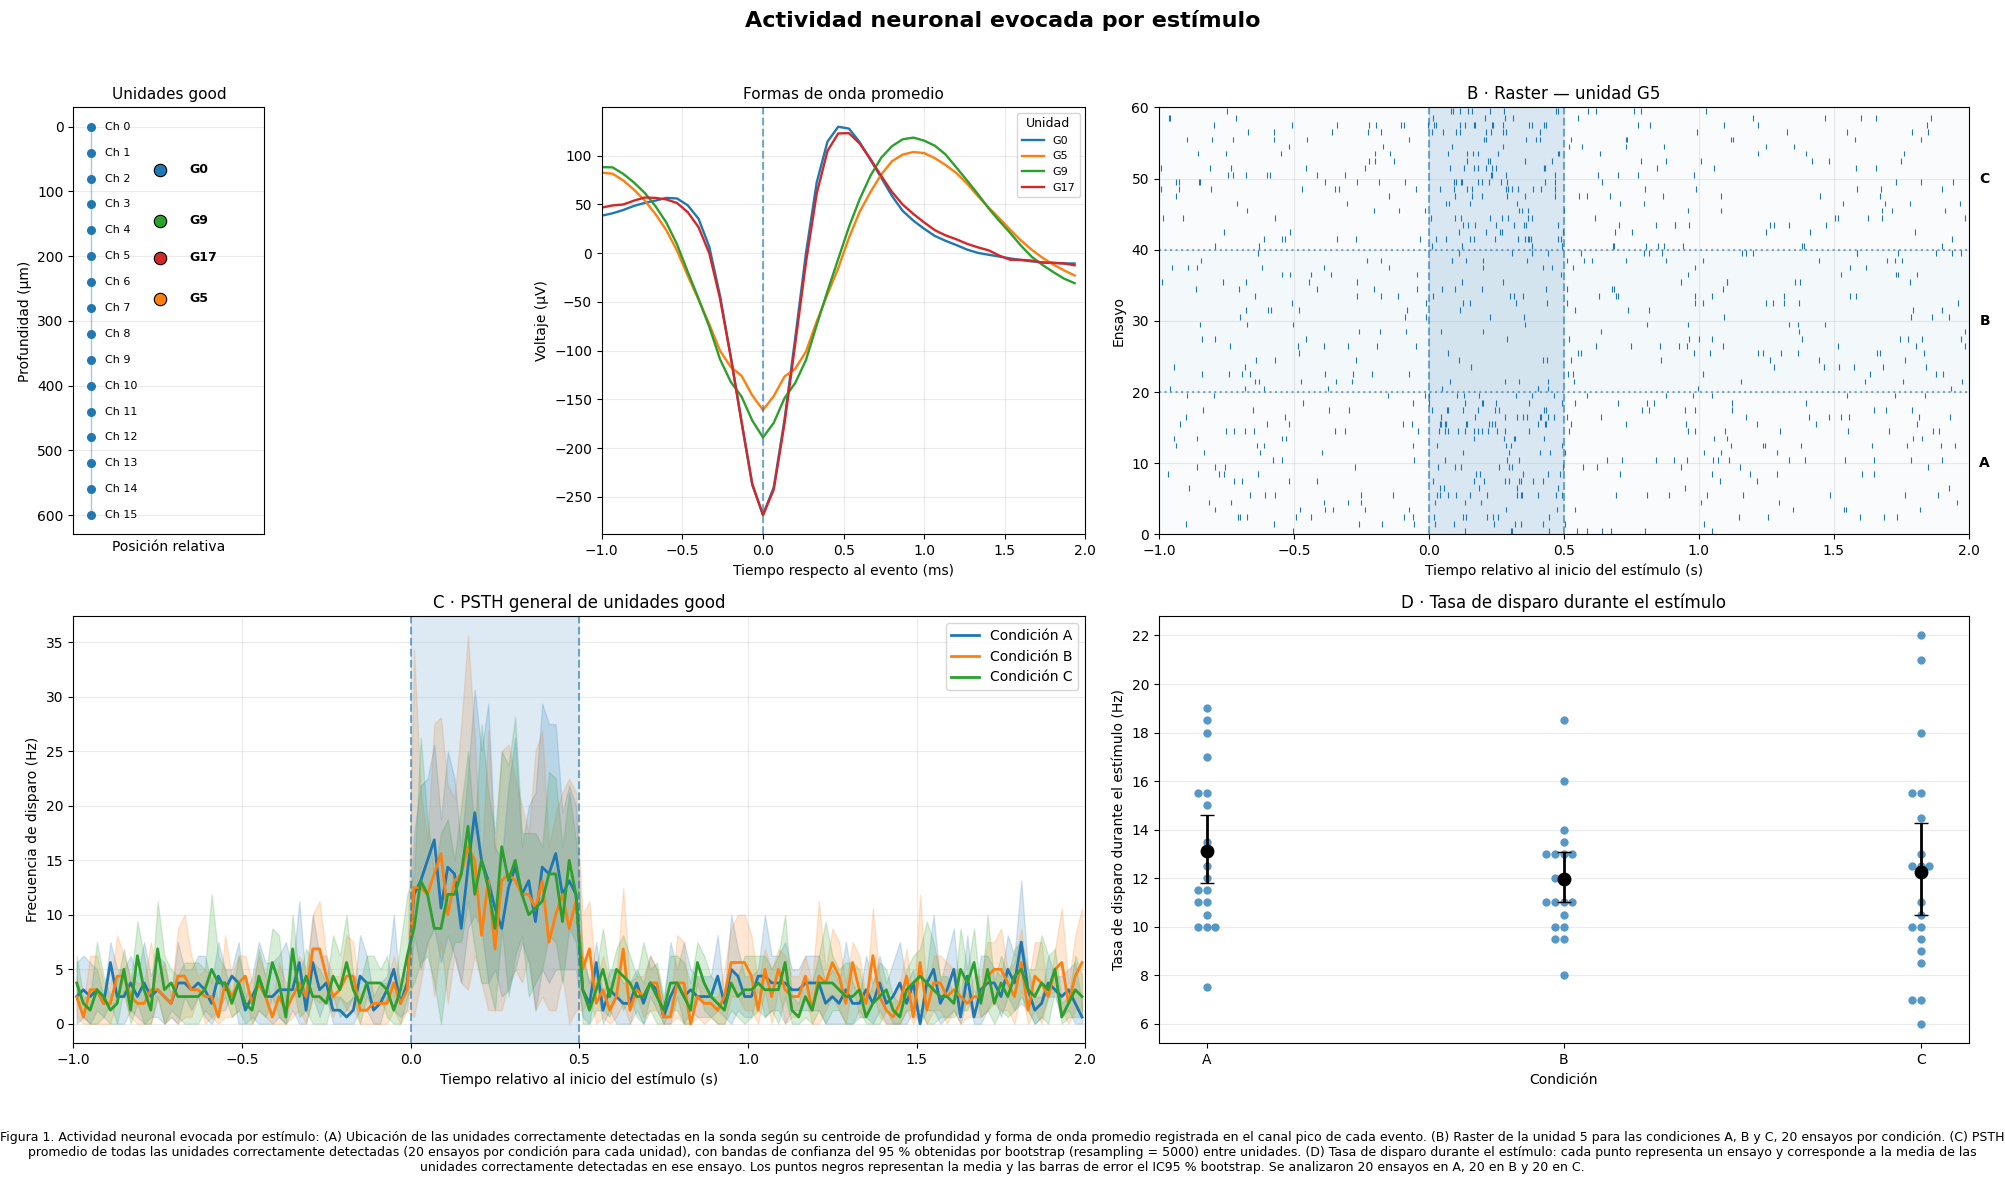

In [ ]:
# ✏️ Ejercicio 11
# ============================================================
# EJERCICIO 11 · FIGURA FINAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 0. PARÁMETROS
# ============================================================

# ============================================================
# ESCRIBE AQUÍ EL NÚMERO DE LA UNIDAD QUE QUIERES MOSTRAR
# EN EL PANEL B
# ============================================================
GRUPO_PANEL_B = 5
N_BOOTSTRAP = 5000
CONFIANZA = 0.95

T_INICIO_FINAL = -1.0
T_FIN_FINAL = 2.0

BIN_PSTH_FINAL = 0.020  # 20 ms


# ============================================================
# 1. VERIFICACIONES BÁSICAS
# ============================================================

if len(grupos_good) == 0:
    raise ValueError("No hay unidades etiquetadas como 'good'.")

if GRUPO_PANEL_B not in grupos_good:
    raise ValueError(
        f"El grupo {GRUPO_PANEL_B} no está entre las unidades good: "
        f"{grupos_good}"
    )


# ============================================================
# 2. CENTROIDES VÁLIDOS POR EVENTO
# ============================================================

centroide_v = centroide[mascara_validos]


assert len(centroide_v) == len(formas_v)
assert len(centroide_v) == len(grupos_curados)


# ============================================================
# 3. FUNCIÓN PARA INTERVALO DE CONFIANZA BOOTSTRAP
# ============================================================

def bootstrap_ic_media(
    datos,
    n_bootstrap=5000,
    confianza=0.95,
    random_state=42
):

    datos = np.asarray(
        datos,
        dtype=float
    )

    datos = datos[
        np.isfinite(datos)
    ]

    if len(datos) == 0:
        return np.nan, np.nan

    if len(datos) == 1:
        return datos[0], datos[0]

    rng = np.random.default_rng(
        random_state
    )

    n = len(datos)

    indices = rng.integers(
        0,
        n,
        size=(n_bootstrap, n)
    )

    medias = np.mean(
        datos[indices],
        axis=1
    )

    alfa = 1 - confianza

    inferior = np.percentile(
        medias,
        100 * alfa / 2
    )

    superior = np.percentile(
        medias,
        100 * (1 - alfa / 2)
    )

    return inferior, superior


# ============================================================
# 4. FUNCIÓN PARA EL PSTH DE UNA UNIDAD Y CONDICIÓN
# ============================================================

def psth_unidad_condicion(
    grupo,
    condicion
):

    ensayos_condicion = np.where(
        etiquetas_ensayo == condicion
    )[0]

    n_ensayos = len(
        ensayos_condicion
    )

    mascara = (
        (grupos_eventos_en_ensayo == grupo)
        &
        (condiciones == condicion)
    )

    spikes = tiempos_relativos[
        mascara
    ]

    bordes = np.arange(
        T_INICIO_FINAL,
        T_FIN_FINAL + BIN_PSTH_FINAL,
        BIN_PSTH_FINAL
    )

    conteos, _ = np.histogram(
        spikes,
        bins=bordes
    )

    centros = (
        bordes[:-1]
        + bordes[1:]
    ) / 2

    tasa_hz = (
        conteos
        / (n_ensayos * BIN_PSTH_FINAL)
    )

    return centros, tasa_hz


# ============================================================
# 5. CREAR FIGURA
# ============================================================

fig = plt.figure(
    figsize=(20, 12),
    constrained_layout=True
)

gs = fig.add_gridspec(
    2,
    2,
    width_ratios=[1.25, 1.0],
    height_ratios=[1.0, 1.0]
)


# ============================================================
# PANEL A
# SONDA + ONDAS PROMEDIO
# ============================================================

gs_A = gs[0, 0].subgridspec(
    1,
    2,
    width_ratios=[0.85, 2.15],
    wspace=1.00
)

ax_probe = fig.add_subplot(
    gs_A[0, 0]
)

ax_wave = fig.add_subplot(
    gs_A[0, 1]
)


# ============================================================
# COLORES DE LAS UNIDADES
# ============================================================

colores = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]


# ============================================================
# SONDA
# ============================================================

ax_probe.plot(
    np.zeros(len(profundidad)),
    profundidad,
    "-",
    linewidth=1,
    alpha=0.4
)

ax_probe.scatter(
    np.zeros(len(profundidad)),
    profundidad,
    s=30,
    zorder=3
)


# ============================================================
# ETIQUETAS DE LOS CANALES
# ============================================================

for canal, profundidad_canal in enumerate(
    profundidad
):

    ax_probe.text(
        0.025,
        profundidad_canal,
        f"Ch {canal}",
        va="center",
        fontsize=8
    )


# ============================================================
# UNIDADES GOOD
# ============================================================

centroides_grupo = {}

for i, grupo in enumerate(
    grupos_good
):

    mascara_grupo = (
        grupos_curados == grupo
    )

    profundidad_grupo = np.mean(
        centroide_v[mascara_grupo]
    )

    centroides_grupo[grupo] = (
        profundidad_grupo
    )

    ax_probe.scatter(
        0.12,
        profundidad_grupo,
        s=80,
        color=colores[i % len(colores)],
        edgecolor="black",
        linewidth=0.8,
        zorder=5
    )

    # Etiqueta de la unidad:
    # la dejamos más cerca de la sonda
    # para evitar invadir el siguiente subplot
    ax_probe.text(
        0.17,
        profundidad_grupo,
        f"G{grupo}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# FORMATO DE LA SONDA
# ============================================================

ax_probe.set_title(
    "Unidades good",
    fontsize=11
)

ax_probe.set_xlabel(
    "Posición relativa"
)

ax_probe.set_ylabel(
    "Profundidad (µm)"
)

ax_probe.set_xticks([])

# Espacio horizontal suficiente para las etiquetas,
# pero sin acercarnos demasiado al siguiente subplot
ax_probe.set_xlim(
    -0.03,
    0.30
)

ax_probe.invert_yaxis()


# ============================================================
# ONDAS PROMEDIO
# ============================================================

t_onda_ms = (
    np.arange(formas_v.shape[2])
    / fs
    * 1000
    - 1
)


for i, grupo in enumerate(
    grupos_good
):

    mascara_grupo = (
        grupos_curados == grupo
    )

    indices_grupo = np.where(
        mascara_grupo
    )[0]

    canales_grupo = (
        canales_metricas[indices_grupo]
    )

    ondas = formas_v[
        indices_grupo,
        canales_grupo,
        :
    ]

    onda_promedio = np.mean(
        ondas,
        axis=0
    )

    ax_wave.plot(
        t_onda_ms,
        onda_promedio,
        linewidth=1.7,
        color=colores[i % len(colores)],
        label=f"G{grupo}"
    )


# ============================================================
# REFERENCIA TEMPORAL
# ============================================================

ax_wave.axvline(
    0,
    linestyle="--",
    alpha=0.6
)


# ============================================================
# FORMATO DE LAS ONDAS
# ============================================================

ax_wave.set_title(
    "Formas de onda promedio",
    fontsize=11
)

ax_wave.set_xlabel(
    "Tiempo respecto al evento (ms)"
)

ax_wave.set_ylabel(
    "Voltaje (µV)"
)

ax_wave.set_xlim(
    -1,
    2
)

ax_wave.legend(
    title="Unidad",
    fontsize=8,
    title_fontsize=9
)

# ============================================================
# PANEL B
# RASTER DE UNA UNIDAD
# ============================================================

ax_B = fig.add_subplot(
    gs[0, 1]
)


# ============================================================
# 1. CONTADOR DE FILAS PARA NO SUPERPONER LAS CONDICIONES
# ============================================================

fila_inicial = 0

limites_condiciones = {}


# ============================================================
# 2. DIBUJAR CADA CONDICIÓN
# ============================================================

for condicion in CONDICIONES:

    # Ensayos pertenecientes a esta condición
    ensayos_condicion = np.where(
        etiquetas_ensayo == condicion
    )[0]

    n_ensayos_condicion = len(
        ensayos_condicion
    )

    # Guardar dónde empieza y termina esta condición
    limites_condiciones[condicion] = (
        fila_inicial,
        fila_inicial + n_ensayos_condicion
    )

    # --------------------------------------------------------
    # Dibujar los ensayos de esta condición
    # --------------------------------------------------------

    for fila, ensayo in enumerate(
        ensayos_condicion
    ):

        # IMPORTANTE:
        # La fila ahora es global, no vuelve a empezar en 0
        fila_global = fila_inicial + fila

        mascara = (
            (grupos_eventos_en_ensayo == GRUPO_PANEL_B)
            &
            (condiciones == condicion)
            &
            (numeros_ensayo == ensayo)
        )

        spikes = tiempos_relativos[
            mascara
        ]

        for spike in spikes:

            ax_B.vlines(
                spike,
                fila_global + 0.1,
                fila_global + 0.9,
                linewidth=0.8
            )

    # Avanzar el contador para la siguiente condición
    fila_inicial += n_ensayos_condicion


# ============================================================
# 3. VENTANA DEL ESTÍMULO
# ============================================================

ax_B.axvspan(
    0,
    0.5,
    alpha=0.15
)

ax_B.axvline(
    0,
    linestyle="--",
    alpha=0.6
)

ax_B.axvline(
    0.5,
    linestyle="--",
    alpha=0.6
)


# ============================================================
# 4. LÍNEAS DE SEPARACIÓN ENTRE CONDICIONES
# ============================================================

inicio_A, fin_A = limites_condiciones["A"]
inicio_B, fin_B = limites_condiciones["B"]
inicio_C, fin_C = limites_condiciones["C"]

ax_B.axhline(
    fin_A,
    linestyle=":",
    alpha=0.6
)

ax_B.axhline(
    fin_B,
    linestyle=":",
    alpha=0.6
)


# ============================================================
# 5. FONDOS SUAVES PARA DIFERENCIAR LAS CONDICIONES
# ============================================================

ax_B.axhspan(
    inicio_A,
    fin_A,
    alpha=0.025
)

ax_B.axhspan(
    inicio_B,
    fin_B,
    alpha=0.05
)

ax_B.axhspan(
    inicio_C,
    fin_C,
    alpha=0.025
)


# ============================================================
# 6. RÓTULOS DE LAS CONDICIONES
# ============================================================

ax_B.text(
    T_FIN_FINAL + 0.04,
    (inicio_A + fin_A) / 2,
    "A",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax_B.text(
    T_FIN_FINAL + 0.04,
    (inicio_B + fin_B) / 2,
    "B",
    va="center",
    fontsize=10,
    fontweight="bold"
)

ax_B.text(
    T_FIN_FINAL + 0.04,
    (inicio_C + fin_C) / 2,
    "C",
    va="center",
    fontsize=10,
    fontweight="bold"
)


# ============================================================
# 7. FORMATO DEL PANEL
# ============================================================

ax_B.set_title(
    f"B · Raster — unidad G{GRUPO_PANEL_B}"
)

ax_B.set_xlabel(
    "Tiempo relativo al inicio del estímulo (s)"
)

ax_B.set_ylabel(
    "Ensayo"
)

ax_B.set_xlim(
    T_INICIO_FINAL,
    T_FIN_FINAL
)

ax_B.set_ylim(
    0,
    fila_inicial
)
# ============================================================
# PANEL C
# PSTH GENERAL DE TODAS LAS UNIDADES GOOD
# ============================================================

ax_C = fig.add_subplot(
    gs[1, 0]
)


for i, condicion in enumerate(
    CONDICIONES
):

    # --------------------------------------------------------
    # Calcular PSTH de cada unidad
    # --------------------------------------------------------

    psths = []

    centros = None

    for grupo in grupos_good:

        centros, tasa = psth_unidad_condicion(
            grupo,
            condicion
        )

        psths.append(
            tasa
        )

    psths = np.asarray(
        psths
    )

    # --------------------------------------------------------
    # Promedio entre unidades
    # --------------------------------------------------------

    media_psth = np.mean(
        psths,
        axis=0
    )

    # --------------------------------------------------------
    # Bootstrap del promedio entre unidades
    # --------------------------------------------------------

    n_unidades = psths.shape[0]

    rng = np.random.default_rng(
        42 + i
    )

    indices_bootstrap = rng.integers(
        0,
        n_unidades,
        size=(N_BOOTSTRAP, n_unidades)
    )

    medias_bootstrap = np.mean(
        psths[indices_bootstrap],
        axis=1
    )

    ic_inferior = np.percentile(
        medias_bootstrap,
        2.5,
        axis=0
    )

    ic_superior = np.percentile(
        medias_bootstrap,
        97.5,
        axis=0
    )

    color = colores[
        i % len(colores)
    ]

    ax_C.plot(
        centros,
        media_psth,
        linewidth=2,
        color=color,
        label=f"Condición {condicion}"
    )

    ax_C.fill_between(
        centros,
        ic_inferior,
        ic_superior,
        color=color,
        alpha=0.18
    )


# ------------------------------------------------------------
# Ventana del estímulo
# ------------------------------------------------------------

ax_C.axvspan(
    0,
    0.5,
    alpha=0.15
)

ax_C.axvline(
    0,
    linestyle="--",
    alpha=0.6
)

ax_C.axvline(
    0.5,
    linestyle="--",
    alpha=0.6
)


ax_C.set_title(
    "C · PSTH general de unidades good"
)

ax_C.set_xlabel(
    "Tiempo relativo al inicio del estímulo (s)"
)

ax_C.set_ylabel(
    "Frecuencia de disparo (Hz)"
)

ax_C.set_xlim(
    T_INICIO_FINAL,
    T_FIN_FINAL
)

ax_C.legend()


# ============================================================
# PANEL D
# SWARMPLOT POR ESTÍMULO
# ============================================================

ax_D = fig.add_subplot(
    gs[1, 1]
)


tasas_por_condicion = {}

for condicion in CONDICIONES:

    tasas_unidades = []

    for grupo in grupos_good:

        tasas = tasa_por_ensayo(
            grupo,
            condicion,
            tiempos_relativos,
            numeros_ensayo,
            grupos_eventos_en_ensayo,
            condiciones,
            etiquetas_ensayo,
            0.0,
            0.5
        )

        tasas_unidades.append(
            tasas
        )

    tasas_unidades = np.asarray(
        tasas_unidades
    )

    # --------------------------------------------------------
    # Un punto = un ensayo
    # Cada punto es la media de las unidades good
    # --------------------------------------------------------

    tasas_ensayo = np.mean(
        tasas_unidades,
        axis=0
    )

    tasas_por_condicion[
        condicion
    ] = tasas_ensayo


# ------------------------------------------------------------
# Construir DataFrame para swarmplot
# ------------------------------------------------------------

datos_swarm = []

for condicion in CONDICIONES:

    for tasa in tasas_por_condicion[
        condicion
    ]:

        datos_swarm.append({
            "Condición": condicion,
            "Tasa_Hz": tasa
        })


df_swarm = pd.DataFrame(
    datos_swarm
)


# ------------------------------------------------------------
# Swarmplot
# ------------------------------------------------------------

sns.swarmplot(
    data=df_swarm,
    x="Condición",
    y="Tasa_Hz",
    ax=ax_D,
    size=6,
    alpha=0.75
)


# ------------------------------------------------------------
# Media + IC95% bootstrap
# ------------------------------------------------------------

for i, condicion in enumerate(
    CONDICIONES
):

    datos = tasas_por_condicion[
        condicion
    ]

    media = np.mean(
        datos
    )

    ic_inferior, ic_superior = (
        bootstrap_ic_media(
            datos,
            n_bootstrap=N_BOOTSTRAP,
            confianza=CONFIANZA,
            random_state=100 + i
        )
    )

    ax_D.errorbar(
        i,
        media,
        yerr=[
            [media - ic_inferior],
            [ic_superior - media]
        ],
        fmt="o",
        markersize=9,
        capsize=5,
        linewidth=2,
        color="black",
        zorder=10
    )


ax_D.set_title(
    "D · Tasa de disparo durante el estímulo"
)

ax_D.set_xlabel(
    "Condición"
)

ax_D.set_ylabel(
    "Tasa de disparo durante el estímulo (Hz)"
)


# ============================================================
# 6. TÍTULOS Y PIE DE FIGURA
# ============================================================

fig.suptitle(
    "Actividad neuronal evocada por estímulo",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# Número de ensayos por condición
# ------------------------------------------------------------

n_ensayos_condicion = {
    condicion: int(
        np.sum(
            etiquetas_ensayo == condicion
        )
    )
    for condicion in CONDICIONES
}


# ------------------------------------------------------------
# Texto del pie de figura
# ------------------------------------------------------------

pie_figura = (
    "Figura 1. Actividad neuronal evocada por estímulo: (A) Ubicación de las unidades correctamente detectadas en la sonda según "
    "su centroide de profundidad y forma de onda promedio registrada en "
    "el canal pico de cada evento. (B) Raster de la unidad "
    f"{GRUPO_PANEL_B}"
    " para las condiciones A, B y C, 20 ensayos por condición. (C) PSTH promedio de todas las "
    "unidades correctamente detectadas (20 ensayos por condición para cada unidad), con bandas de confianza del 95 % obtenidas por "
    f"bootstrap (resampling = {N_BOOTSTRAP}) entre unidades. (D) Tasa de disparo "
    "durante el estímulo: cada punto representa un ensayo y corresponde "
    "a la media de las unidades correctamente detectadas en ese ensayo. Los puntos negros "
    "representan la media y las barras de error el IC95 % bootstrap. "
    f"Se analizaron {n_ensayos_condicion['A']} ensayos en A, "
    f"{n_ensayos_condicion['B']} en B y "
    f"{n_ensayos_condicion['C']} en C."
)

fig.text(
    0.5,
    0.01,
    pie_figura,
    ha="center",
    va="bottom",
    fontsize=9,
    wrap=True
)


plt.tight_layout(
    rect=[0, 0.07, 1, 0.96]
)

plt.show()

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva
- **c)** la latencia de la respuesta
- **d)** la tasa basal

Respuesta: C

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*
    Figura 1. Actividad neuronal evocada por estímulo: (A) Ubicación de las cuatro unidades correctamente detectadas en la sonda según su centroide de profundidad y forma de onda promedio registrada en el canal pico de cada evento. (B) Raster de la unidad 5 para las condiciones A, B y C, 20 ensayos por condición. (C) PSTH promedio de todas las unidades correctamente detectadas (20 ensayos por condición para cada unidad), con bandas de confianza del 95 % obtenidas por bootstrap (resampling = 5000) entre unidades. (D) Tasa de disparo durante el estímulo: cada punto representa un ensayo y corresponde a la media de las unidades correctamente detectadas en ese ensayo. Los puntos negros representan la media y las barras de error el IC95 % bootstrap. Se analizaron 20 ensayos en A, 20 en B y 20 en C.

---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

**Resultados:**

Se registraron por K-means un total de 24 unidades. Estas fueron agrupadas a 18 unidades de las cuales 4 superaron los filtros de curación. Los criterios de curación que indican la detección de nueronas reales en un grupo fueron:
- Detectar 2 o menos picos y 2 o menos valles por evento
- Duración del evento entre 100-1150 microsegundos
- Pendiente de caída menor a -0.004
- Razón pico/valle menor a 0.8
- Porcentaje de disparos faltantes menor al 20%
- Porcentaje de eventos por debajo del refractario menor al 1.5%
- Al menos 300 potenciales de acción.

Para verificar la respuesta de las unidades a distintas condiciones del estímulo, se calculó un Z-score y se realizó una prueba t pareada (respuesta basal vs respuesta a estímulo) + bootstrap (resampling = 5000), a partir del cual se calculó un intervalo de confianza del 95% de la tasa evocada por estímulo.

Según los resultados de las estadísticas realizadas, las unidades que respondieron al estímulo y las condiciones bajo las que respondieron fueron:
- Unidad 0: condiciones A, B y C
- Unidad 5: condiciones A y C
- Unidad 9: condición A y C
- Unidad 17: condiciones A, B y C

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

**Intercambio 1**

*Prompt:* En Python, quiero comparar diferentes valores de K para un agrupamiento K-means de potenciales de acción. Tengo un array de NumPy con las características extraídas de cada spike: amplitud, media anchura del valle en ms y centroide espacial en µm, previamente estandarizadas. Compara K = 12, K = 16 y K = 24 mediante gráficas de dispersión y ayúdame a determinar cuál evita tanto la fusión de poblaciones diferentes como la fragmentación excesiva de una misma población. Rotula los ejes con sus unidades, explica el criterio utilizado y usa únicamente NumPy, Matplotlib y scikit-learn

*Respuesta del modelo:*

La mejor opción sería K = 20, porque al tener un mayor número de grupos se consigue una separación más detallada de los spikes y se pueden identificar mejor las diferentes neuronas

*Qué estaba mal:*

La IA asumió que un número mayor de clusters necesariamente representa mejor los datos. Además, tomó un valor de K que no metimos en el prompt, y que no analizamos gráficamente.


*Cómo lo corregimos:*

Comparamos visualmente los tres valores. Con K = 12 algunas poblaciones diferentes quedaban fusionadas y, aunque con K = 24 aparecía sobrefragmentación, preferimos utilizar un K alto y luego agrupar grupos en la sección de curación para asegurarnos que los grupos hallados con K = 16 fueran realmente grupos reales.

**Intercambio 2**

*Prompt:*

En Python, quiero calcular y analizar el autocorrelograma de los tiempos de disparo de una unidad neuronal para evaluar la calidad del aislamiento. Tengo un array de NumPy con los tiempos de los spikes en segundos obtenidos de una grabación extracelular. Construye un autocorrelograma centrado en Δt = 0 y evalúa especialmente los intervalos correspondientes al período refractario de aproximadamente 2 ms. Quiero que los ejes estén rotulados con unidades, que calcules el porcentaje de violaciones del período refractario y que expliques cómo interpretar el resultado fisiológicamente, utilizando únicamente NumPy y Matplotlib.

*Respuesta del modelo:*
Si aparecen muchos eventos muy cerca de Δt = 0, esto indica que la unidad está bien aislada porque la neurona está disparando repetidamente en intervalos muy cortos.

*Qué estaba mal:*

La interpretación era incorrecta porque una misma neurona no debería generar dos potenciales de acción dentro de su período refractario. Por lo tanto, una gran cantidad de eventos muy cerca de cero puede indicar contaminación del cluster por spikes provenientes de otras unidades.

*Cómo lo corregimos:*

Revisamos la disminución de eventos alrededor de Δt = 0 y calculamos el porcentaje de violaciones del período refractario. En nuestro análisis utilizamos este porcentaje como una de las métricas para decidir la calidad de cada grupo.

**Intercambio 3**

*Prompt:* Debemos hacer una figura recopilatoria final de cuatro paneles, con todas las unidades good juntas.

Panel A. La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de onda promedio de cada una.
Panel B. El raster de una sola unidad, con las tres condiciones. Déjame el espacio para que yo escoja la unidad a graficar, e indícame donde ingresarla con un comentario en mayúsculas.
Panel C. El PSTH general por estímulo: todas las unidades good promediadas, una curva por condición. Añade banda de confianza.
Panel D. El swarmplot por estímulo: un punto por ensayo, agrupados por condición, con la media y su intervalo de confianza encima.

Reglas de formato para todos los paneles:

1. Todos los ejes con unidades.
2. Escalas de tiempo iguales entre paneles.
3. Distingue entre categorías (no uses distinción verde/rojo).
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Añade rótulos donde la figura pueda requerir explicaciones.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

*Respuesta del modelo:*
Se genrea la figura con la siguiente estructura
* **A:** sonda + centroides de las unidades good + onda promedio de cada unidad.
* **B:** raster de una unidad que tú escoges.
* **C:** PSTH poblacional de todas las good.
* **D:** swarmplot de la tasa durante el estímulo, un punto por ensayo.

"En C, la curva poblacional se obtiene dando el mismo peso a cada unidad. En D, cada punto representa la **media de las unidades good para ese ensayo**, por lo que siguen siendo exactamente 20 puntos por condición y no convertimos artificialmente cada combinación unidad×ensayo en una observación independiente."

*Qué estaba mal:* En el Panel B solo se está mostrando el PSTH del estímulo A.

*Cómo lo corregimos:* Se le pidió a la IA que se explicara la fuente del error (que era de display de la figura, no de manejo de los datos). Nos devolvió un código para reemplazar el display del panel B y una comparación del nuevo código con el anterior, con explicación en palabras.

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas
- **d)** estandarizar las características antes de K-means

Selección múltiple: C

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*


Una decisión que no vemos fácil de automatizar completamente fue decidir si dos grupos cercanos correspondían a la misma neurona o a dos neuronas vecinas. Por ejemplo, para decidir fusionar los grupos 0 y 18 no bastaba con observar que el correlograma cruzado tenía una banda refractaria casi vacía, porque este patrón también puede aparecer entre dos neuronas cercanas. Fue necesario comparar además sus formas de onda promedio y evaluar si eran suficientemente similares antes de decidir fusionarlos.

En cambio, sí automatizaríamos la clasificación inicial de los grupos a partir de criterios cuantitativos, como el porcentaje de violaciones del período refractario, el porcentaje de disparos faltantes, la pendiente de caída espacial, la razón pico/valle y el número de disparos. Estas medidas pueden compararse automáticamente con umbrales definidos para identificar grupos que claramente cumplen o incumplen los criterios de calidad.



---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [ ]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "B",   "P2":  "B",   "P3":  "D",   "P4":  "B",
    "P5":  "C",   "P6":  "B",   "P7":  "D",   "P8":  "B",
    "P9":  "B",   "P10": "B",   "P11": "C",   "P12": "C",
}

numeros = {
    "eventos_limpia":        2705,   # sección 2
    "eventos_ruidosa":       18546,   # sección 4
    "k_elegido":             24,   # sección 4
    "grupos_good":           4,   # sección 7
    "grupos_mua":            9,   # sección 7
    "grupos_nonsomatic":     0,   # sección 7
    "grupos_noise":          5,   # sección 7
    "identificable_antes":   0.653,   # sección 8
    "identificable_despues": 0.959,   # sección 8
    "precision_despues":             1.0,   # sección 8
    "exhaustividad_despues":         0.25,   # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


selección múltiple
    P1  b
    P2  b
    P3  d
    P4  b
    P5  c
    P6  b
    P7  d
    P8  b
    P9  b
   P10  b
   P11  c
   P12  c

números del pipeline
          eventos_limpia  2705
         eventos_ruidosa  18546
               k_elegido  24
             grupos_good  4
              grupos_mua  9
       grupos_nonsomatic  0
            grupos_noise  5
     identificable_antes  0.653
   identificable_despues  0.959
       precision_despues  1.0
   exhaustividad_despues  0.25

sin llenar: ninguno


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.